# Analisi biometrica per la sezione Results

Estende l'analisi originale (limitata a resnet34) a tutti i backbone
disponibili, e aggiunge quanto necessario per una sezione Results
accademicamente solida in ambito biometrico:

1. Tabella di protocollo (n. coppie genuine/impostor per configurazione)
2. Bootstrap CI al 95% su EER e AUC
3. DET curve (gia' presenti, mantenute)
4. Controllo di normalita' delle distribuzioni genuine/impostor
   (assunzione implicita di d-prime/decidability)
5. Aggregazione cross-backbone con errore standard
6. Test di Wilcoxon a coppie appaiate (loss vs loss) su AUC, con effect size
7. Blocco esplicito di dichiarazione dei confondimenti noti
   (frozen_layers, embedding_dim, batch_size non uniformi tra le loss)

Bug corretti rispetto alla versione precedente:
- confusion_matrix poteva fallire se al threshold EER una classe sparisce
  dalle predizioni (aggiunto `labels=[0,1]`)
- stile matplotlib non garantito disponibile su tutte le installazioni
  (fallback silenzioso)
- l'aggregazione Same/Cross dataset era calcolata su un solo modello:
  ora aggrega su tutti i backbone disponibili, con media +/- deviazione
  standard invece di un singolo valore puntuale

In [1]:
import warnings
warnings.filterwarnings('ignore')

import ast
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, auc, confusion_matrix

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except (OSError, ValueError):
    plt.style.use('default')
sns.set_palette("husl")

Path('./images').mkdir(exist_ok=True)

## Configurazione

In [2]:
results_base = Path('../results')

loss_types = ['bce', 'contrastive', 'triplet']
dataset_combinations = ['iam_to_iam', 'iam_to_rimes', 'rimes_to_iam', 'rimes_to_rimes']

# Tutti i backbone disponibili: necessari per avere n sufficiente nei test
# di significativita' e nell'aggregazione cross-model. Se hai lanciato solo
# un sottoinsieme di backbone, aggiornalo qui.
MODELS_TO_ANALYZE = [
    'efficientnet_b0', 'efficientnet_b1',
    'mobilenet_v3_large', 'mobilenet_v3_small',
    'resnet18', 'resnet34',
]

# Modello usato per i grafici "di dettaglio" (distribuzioni, ROC, DET,
# training history) dove mostrare tutti i backbone in un'unica griglia
# sarebbe illeggibile.
REPRESENTATIVE_MODEL = 'resnet34'

N_BOOTSTRAP = 1000          # ricampionamenti per il bootstrap CI
CI_LEVEL = 95                # livello di confidenza (%)
BOOTSTRAP_SEED = 42

## Caricamento dati

Prova prima il pattern `results_base/{loss}/{loss}_experiments/...`
(organizzazione locale), poi come fallback `results_base/{loss}_experiments/...`
(struttura di output originale degli script di training). Se nessuno dei
due esiste, la configurazione viene semplicemente saltata (loggato a schermo).

In [3]:
def resolve_experiment_path(loss, model_name, dataset_comb):
    experiment_name = f"{model_name}_{loss}_{dataset_comb}"
    candidates = [
        results_base / loss / f"{loss}_experiments" / experiment_name,
        results_base / f"{loss}_experiments" / experiment_name,
    ]
    for c in candidates:
        if (c / f"{experiment_name}_final_metrics.csv").exists():
            return c, experiment_name
    return None, experiment_name


all_results = {}
missing_configs = []

for loss in loss_types:
    all_results[loss] = {}
    for model_name in MODELS_TO_ANALYZE:
        for dataset_comb in dataset_combinations:
            experiment_path, experiment_name = resolve_experiment_path(loss, model_name, dataset_comb)

            if experiment_path is None:
                missing_configs.append(experiment_name)
                continue

            metrics_file = experiment_path / f"{experiment_name}_final_metrics.csv"
            history_file = experiment_path / f"{experiment_name}_history.csv"

            if not (metrics_file.exists() and history_file.exists()):
                missing_configs.append(experiment_name)
                continue

            metrics_df = pd.read_csv(metrics_file)
            history_df = pd.read_csv(history_file)

            genuine_vals = np.array(ast.literal_eval(metrics_df['genuine_vals'].values[0]))
            impostor_vals = np.array(ast.literal_eval(metrics_df['impostor_vals'].values[0]))

            all_results[loss].setdefault(model_name, {})[dataset_comb] = {
                'metrics': metrics_df,
                'history': history_df,
                'genuine_vals': genuine_vals,
                'impostor_vals': impostor_vals,
            }

print(f"Configurazioni caricate: {sum(len(m) for l in all_results.values() for m in l.values())}")
print(f"Configurazioni mancanti/saltate: {len(missing_configs)}")
if missing_configs:
    print("  " + ", ".join(missing_configs[:10]) + (" ..." if len(missing_configs) > 10 else ""))

Configurazioni caricate: 72
Configurazioni mancanti/saltate: 0


## 1. Tabella di protocollo

Da riportare esplicitamente nei Results: numero di coppie genuine e
impostor effettivamente valutate per ciascuna configurazione. Necessaria
per giudicare la varianza della stima di EER (coppie poche -> CI larghi).

In [4]:
protocol_rows = []
for loss in loss_types:
    for model_name, splits in all_results.get(loss, {}).items():
        for dataset_comb, data in splits.items():
            protocol_rows.append({
                'loss': loss,
                'model': model_name,
                'split': dataset_comb,
                'n_genuine': len(data['genuine_vals']),
                'n_impostor': len(data['impostor_vals']),
                'n_total': len(data['genuine_vals']) + len(data['impostor_vals']),
            })

protocol_df = pd.DataFrame(protocol_rows)
protocol_df.to_csv('./protocol_table.csv', index=False)
print("Tabella di protocollo (riassunto per split, aggregato su loss e backbone):")
print(protocol_df.groupby('split')[['n_genuine', 'n_impostor', 'n_total']].agg(['mean', 'min', 'max']).round(1))

Tabella di protocollo (riassunto per split, aggregato su loss e backbone):
               n_genuine             n_impostor              n_total         \
                    mean   min   max       mean   min   max     mean    min   
split                                                                         
iam_to_iam         537.0   537   537      537.0   537   537   1074.0   1074   
iam_to_rimes      7175.0  7175  7175     7175.0  7175  7175  14350.0  14350   
rimes_to_iam      4051.0  4051  4051     4051.0  4051  4051   8102.0   8102   
rimes_to_rimes    1444.0  1444  1444     1444.0  1444  1444   2888.0   2888   

                       
                  max  
split                  
iam_to_iam       1074  
iam_to_rimes    14350  
rimes_to_iam     8102  
rimes_to_rimes   2888  


## 1b. Statistiche writer per dataset (Tabella mancante #7)

Questi numeri NON sono nei CSV di output della valutazione (che
contengono solo score e conteggio coppie): vanno presi dai log di
training. Sono gia' stati estratti dai log forniti (esperimenti
resnet18_bce_*) e sono qui pre-compilati. Se rilanci lo sweep con altri
seed/split, aggiorna questo dizionario di conseguenza (i conteggi writer
dipendono solo dallo split dei dati, non da backbone/loss, quindi restano
validi per tutte le 72 configurazioni finche' lo split non cambia).

In [5]:
WRITER_STATS = {
    'IAM': {
        'total_writers': 657,
        'train_pool_writers': 525,   # split 80% per IAM->IAM
        'test_pool_writers': 132,
        'source_full_writers': 657,  # writer usati quando IAM e' sorgente/target cross-dataset
    },
    'RIMES': {
        'total_writers': 1500,
        'train_pool_writers': 1200,  # split 80% per RIMES->RIMES
        'test_pool_writers': 300,
        'source_full_writers': 1500,
    },
}

writer_stats_df = pd.DataFrame(WRITER_STATS).T
writer_stats_df.index.name = 'dataset'
writer_stats_df.to_csv('./writer_stats.csv')

print("=" * 80)
print("STATISTICHE WRITER PER DATASET (estratte dai log di training)")
print("=" * 80)
print(writer_stats_df.to_string())
print("""
Nota: il numero di immagini/righe per writer non e' presente nei log
forniti (solo il conteggio writer e il numero di coppie genuine/impostor
generate). Se disponibile nei metadata del dataset, aggiungere una colonna
'images_per_writer' (media/min/max) a WRITER_STATS per completare la
tabella nei Results.
""")

STATISTICHE WRITER PER DATASET (estratte dai log di training)
         total_writers  train_pool_writers  test_pool_writers  source_full_writers
dataset                                                                           
IAM                657                 525                132                  657
RIMES             1500                1200                300                 1500

Nota: il numero di immagini/righe per writer non e' presente nei log
forniti (solo il conteggio writer e il numero di coppie genuine/impostor
generate). Se disponibile nei metadata del dataset, aggiungere una colonna
'images_per_writer' (media/min/max) a WRITER_STATS per completare la
tabella nei Results.



## 2. Metriche biometriche + Bootstrap CI

`d_prime`/`decidability` sono calcolati direttamente sugli score raw
genuine/impostor (score piu' alto = piu' simile, convenzione unificata
per BCE/contrastive/triplet in fase di validazione). Il bootstrap
ricampiona con reinserimento i vettori di score gia' salvati: non serve
rifare training per ottenere l'intervallo di confidenza.

In [6]:
def calculate_biometric_metrics(genuine_scores, impostor_scores):
    """Metriche biometriche standard. Assume score piu' alto = piu' simile
    (vale sia per l'output sigmoid della BCE sia per la cosine similarity
    di contrastive/triplet, come verificato nel trainer)."""

    mu_genuine = np.mean(genuine_scores)
    mu_impostor = np.mean(impostor_scores)
    sigma_genuine = np.std(genuine_scores, ddof=1)
    sigma_impostor = np.std(impostor_scores, ddof=1)

    pooled_std = np.sqrt(0.5 * (sigma_genuine**2 + sigma_impostor**2))
    d_prime = (mu_genuine - mu_impostor) / pooled_std if pooled_std > 0 else 0.0
    decidability = abs(d_prime)

    y_true = np.concatenate([np.ones(len(genuine_scores)), np.zeros(len(impostor_scores))])
    y_scores = np.concatenate([genuine_scores, impostor_scores])

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    eer_threshold = thresholds[eer_idx]

    def operating_point(far_target):
        idxs = np.where(fpr <= far_target)[0]
        if len(idxs) == 0:
            return dict(far_eff=np.nan, frr=np.nan, gar=np.nan, thr=np.nan)
        idx = idxs[-1]
        return dict(far_eff=fpr[idx], frr=fnr[idx], gar=tpr[idx], thr=thresholds[idx])

    op_0001 = operating_point(0.0001)   # FAR target 0.01%
    op_001 = operating_point(0.001)     # FAR target 0.1%
    op_01 = operating_point(0.01)       # FAR target 1%

    # A FAR=0.01% serve almeno ~1/0.0001 = 10.000 coppie impostor per una
    # stima non degenere (regola del pollice standard in biometria: servono
    # almeno 1/FAR confronti impostor). Sotto questa soglia il punto e'
    # segnato invalido piuttosto che riportato come se fosse affidabile.
    n_impostor_local = len(impostor_scores)
    op_0001_valid = n_impostor_local >= int(1 / 0.0001)
    if not op_0001_valid:
        op_0001 = dict(far_eff=np.nan, frr=np.nan, gar=np.nan, thr=np.nan)

    predictions = (y_scores >= eer_threshold).astype(int)
    accuracy = np.mean(predictions == y_true)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        'auc': roc_auc, 'eer': eer, 'eer_threshold': eer_threshold,
        'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1,
        'd_prime': d_prime, 'decidability': decidability,
        'mu_genuine': mu_genuine, 'mu_impostor': mu_impostor,
        'sigma_genuine': sigma_genuine, 'sigma_impostor': sigma_impostor,
        'fpr': fpr, 'tpr': tpr, 'thresholds': thresholds,
        # FAR target = 0.01% (invalido se n_impostor insufficiente, vedi sopra)
        'far_0001_effective': op_0001['far_eff'], 'frr_at_far_0001': op_0001['frr'],
        'gar_at_far_0001': op_0001['gar'], 'threshold_at_far_0001': op_0001['thr'],
        'far_0001_valid': op_0001_valid,
        # FAR target = 0.1%
        'far_001_effective': op_001['far_eff'], 'frr_at_far_001': op_001['frr'],
        'gar_at_far_001': op_001['gar'], 'threshold_at_far_001': op_001['thr'],
        # FAR target = 1%
        'far_01_effective': op_01['far_eff'], 'frr_at_far_01': op_01['frr'],
        'gar_at_far_01': op_01['gar'], 'threshold_at_far_01': op_01['thr'],
    }


def bootstrap_ci(genuine, impostor, metric='auc', n_boot=N_BOOTSTRAP,
                  ci=CI_LEVEL, seed=BOOTSTRAP_SEED):
    """Bootstrap non parametrico su EER o AUC ricampionando gli score
    genuine/impostor gia' osservati. Ritorna (stima_puntuale, lower, upper)."""
    rng = np.random.default_rng(seed)
    n_g, n_i = len(genuine), len(impostor)
    boot_vals = []

    for _ in range(n_boot):
        g_s = rng.choice(genuine, size=n_g, replace=True)
        i_s = rng.choice(impostor, size=n_i, replace=True)
        y_true = np.concatenate([np.ones(n_g), np.zeros(n_i)])
        y_scores = np.concatenate([g_s, i_s])

        fpr, tpr, _ = roc_curve(y_true, y_scores)
        if metric == 'auc':
            boot_vals.append(auc(fpr, tpr))
        else:  # eer
            fnr = 1 - tpr
            idx = np.nanargmin(np.abs(fnr - fpr))
            boot_vals.append((fpr[idx] + fnr[idx]) / 2)

    boot_vals = np.array(boot_vals)
    alpha = (100 - ci) / 2
    lower, upper = np.percentile(boot_vals, [alpha, 100 - alpha])
    point = np.mean(boot_vals)
    return point, lower, upper

In [8]:
from tqdm.auto import tqdm

computed_metrics = {}

# Calcoliamo prima il numero totale di combinazioni
total_combinations = sum(
    len(splits)
    for loss in loss_types
    for splits in all_results.get(loss, {}).values()
)

with tqdm(
    total=total_combinations,
    desc="Computing biometric metrics",
    unit="split"
) as pbar:

    for loss in loss_types:
        computed_metrics[loss] = {}

        for model_name, splits in all_results.get(loss, {}).items():
            computed_metrics[loss][model_name] = {}

            for dataset_comb, data in splits.items():

                # ---------------------------------------------------------
                # Recupera gli score
                # ---------------------------------------------------------
                genuine = data['genuine_vals']
                impostor = data['impostor_vals']

                # ---------------------------------------------------------
                # Metriche biometriche
                # ---------------------------------------------------------
                m = calculate_biometric_metrics(
                    genuine,
                    impostor
                )

                # ---------------------------------------------------------
                # Bootstrap CI - AUC
                # ---------------------------------------------------------
                _, auc_lo, auc_hi = bootstrap_ci(
                    genuine,
                    impostor,
                    metric='auc'
                )

                # ---------------------------------------------------------
                # Bootstrap CI - EER
                # ---------------------------------------------------------
                _, eer_lo, eer_hi = bootstrap_ci(
                    genuine,
                    impostor,
                    metric='eer'
                )

                # ---------------------------------------------------------
                # Salva confidence intervals
                # ---------------------------------------------------------
                m['auc_ci_low'] = auc_lo
                m['auc_ci_high'] = auc_hi

                m['eer_ci_low'] = eer_lo
                m['eer_ci_high'] = eer_hi

                # ---------------------------------------------------------
                # Salva risultati
                # ---------------------------------------------------------
                computed_metrics[loss][model_name][dataset_comb] = m

                # Aggiorna progress bar
                pbar.set_postfix({
                    "loss": loss,
                    "model": model_name,
                    "split": dataset_comb
                })
                pbar.update(1)


# ============================================================================
# Esempio risultati
# ============================================================================

print(
    "\nEsempio con CI "
    "(loss, modello, split -> AUC [CI95%], EER [CI95%]):"
)

for loss in loss_types:
    for model_name in list(computed_metrics[loss].keys())[:1]:

        for dataset_comb, m in computed_metrics[loss][model_name].items():

            print(
                f"  {loss}/{model_name}/{dataset_comb}: "
                f"AUC={m['auc']:.3f} "
                f"[{m['auc_ci_low']:.3f}-{m['auc_ci_high']:.3f}]  "
                f"EER={m['eer']:.3f} "
                f"[{m['eer_ci_low']:.3f}-{m['eer_ci_high']:.3f}]"
            )

Computing biometric metrics:   0%|          | 0/72 [00:00<?, ?split/s]

Computing biometric metrics: 100%|██████████| 72/72 [06:20<00:00,  5.28s/split, loss=triplet, model=resnet34, split=rimes_to_rimes]              


Esempio con CI (loss, modello, split -> AUC [CI95%], EER [CI95%]):
  bce/efficientnet_b0/iam_to_iam: AUC=0.942 [0.928-0.956]  EER=0.088 [0.072-0.105]
  bce/efficientnet_b0/iam_to_rimes: AUC=0.515 [0.510-0.521]  EER=0.485 [0.479-0.490]
  bce/efficientnet_b0/rimes_to_iam: AUC=0.551 [0.539-0.563]  EER=0.454 [0.443-0.464]
  bce/efficientnet_b0/rimes_to_rimes: AUC=0.847 [0.832-0.861]  EER=0.223 [0.206-0.238]
  contrastive/efficientnet_b0/iam_to_iam: AUC=0.962 [0.952-0.972]  EER=0.104 [0.088-0.126]
  contrastive/efficientnet_b0/iam_to_rimes: AUC=0.710 [0.702-0.718]  EER=0.344 [0.336-0.352]
  contrastive/efficientnet_b0/rimes_to_iam: AUC=0.865 [0.858-0.873]  EER=0.203 [0.194-0.213]
  contrastive/efficientnet_b0/rimes_to_rimes: AUC=0.901 [0.889-0.911]  EER=0.162 [0.149-0.178]
  triplet/efficientnet_b0/iam_to_iam: AUC=0.810 [0.785-0.834]  EER=0.257 [0.229-0.283]
  triplet/efficientnet_b0/iam_to_rimes: AUC=0.635 [0.626-0.645]  EER=0.413 [0.404-0.422]
  triplet/efficientnet_b0/rimes_to_iam: AUC=

## 3. Controllo di normalita' delle distribuzioni genuine/impostor

d-prime e decidability assumono implicitamente distribuzioni
approssimativamente gaussiane. Va verificato e dichiarato, non dato per
scontato. Shapiro-Wilk su un sottocampione (il test perde potenza/affidabilita'
oltre alcune migliaia di osservazioni).

In [9]:
def normality_check(genuine, impostor, max_n=5000, seed=42):
    rng = np.random.default_rng(seed)
    g = genuine if len(genuine) <= max_n else rng.choice(genuine, max_n, replace=False)
    i = impostor if len(impostor) <= max_n else rng.choice(impostor, max_n, replace=False)
    _, p_g = stats.shapiro(g)
    _, p_i = stats.shapiro(i)
    return p_g, p_i


normality_rows = []
for loss in loss_types:
    for model_name, splits in computed_metrics[loss].items():
        for dataset_comb in splits:
            genuine = all_results[loss][model_name][dataset_comb]['genuine_vals']
            impostor = all_results[loss][model_name][dataset_comb]['impostor_vals']
            p_g, p_i = normality_check(genuine, impostor)
            normality_rows.append({
                'loss': loss, 'model': model_name, 'split': dataset_comb,
                'shapiro_p_genuine': p_g, 'shapiro_p_impostor': p_i,
                'genuine_normal_a5pct': p_g > 0.05,
                'impostor_normal_a5pct': p_i > 0.05,
            })

normality_df = pd.DataFrame(normality_rows)
normality_df.to_csv('./normality_check.csv', index=False)

pct_normal_genuine = normality_df['genuine_normal_a5pct'].mean() * 100
pct_normal_impostor = normality_df['impostor_normal_a5pct'].mean() * 100
print(f"Distribuzioni genuine compatibili con normalita' (Shapiro-Wilk, alpha=0.05): {pct_normal_genuine:.1f}% delle configurazioni")
print(f"Distribuzioni impostor compatibili con normalita' (Shapiro-Wilk, alpha=0.05): {pct_normal_impostor:.1f}% delle configurazioni")
print("Nota: con n grandi, Shapiro-Wilk rifiuta la normalita' anche per scostamenti")
print("marginali; da leggere insieme agli istogrammi qualitativi sotto, non da soli.")

Distribuzioni genuine compatibili con normalita' (Shapiro-Wilk, alpha=0.05): 0.0% delle configurazioni
Distribuzioni impostor compatibili con normalita' (Shapiro-Wilk, alpha=0.05): 0.0% delle configurazioni
Nota: con n grandi, Shapiro-Wilk rifiuta la normalita' anche per scostamenti
marginali; da leggere insieme agli istogrammi qualitativi sotto, non da soli.


## 4. Distribuzioni degli score (con overlay gaussiano) — modello rappresentativo

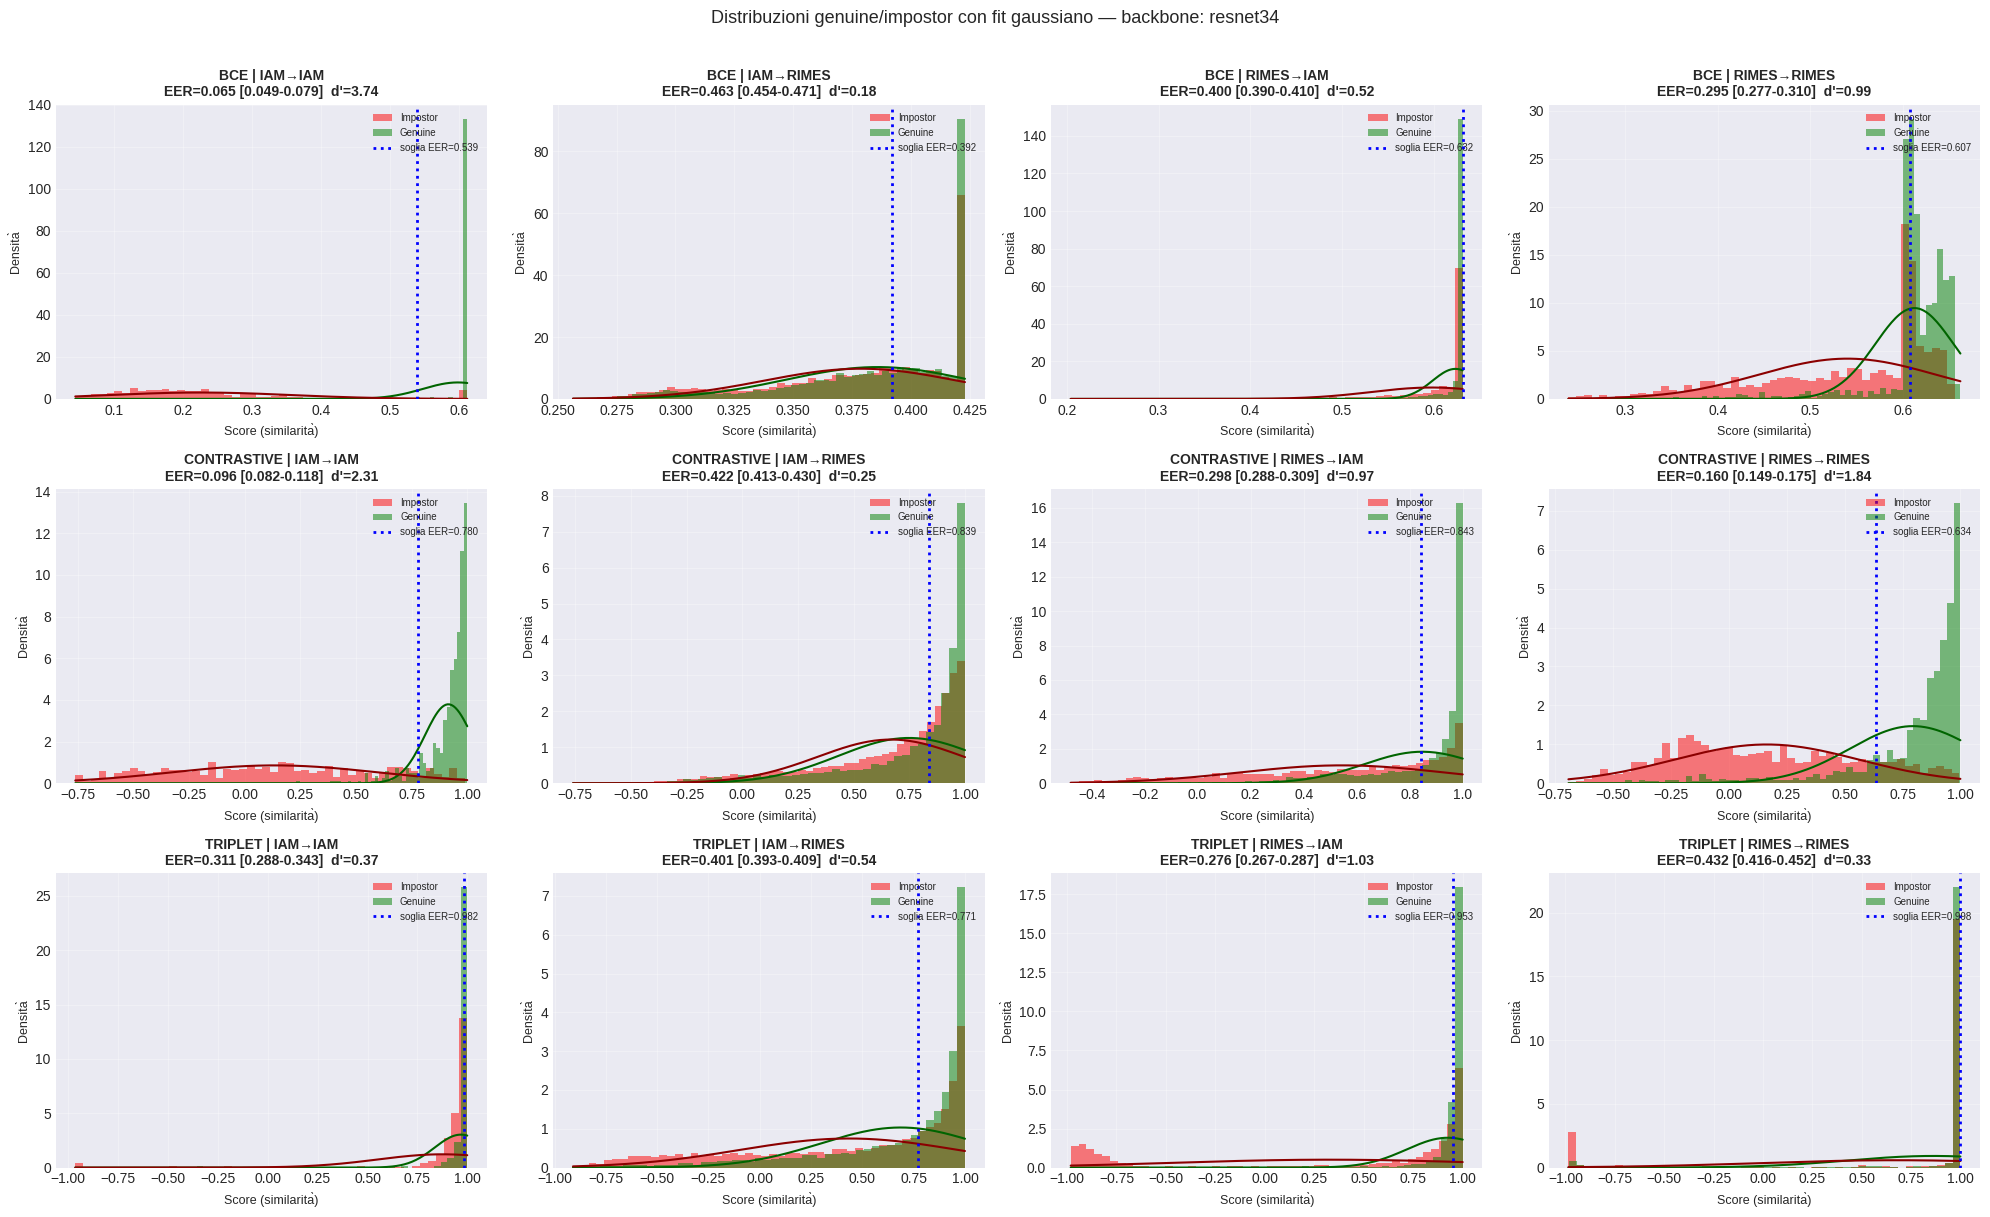

In [10]:
def plot_score_distributions(model_name):
    fig, axes = plt.subplots(len(loss_types), len(dataset_combinations),
                              figsize=(20, 4 * len(loss_types)))

    for i, loss in enumerate(loss_types):
        for j, dataset_comb in enumerate(dataset_combinations):
            ax = axes[i, j]
            data = all_results.get(loss, {}).get(model_name, {}).get(dataset_comb)
            if data is None:
                ax.axis('off')
                continue

            genuine = data['genuine_vals']
            impostor = data['impostor_vals']
            m = computed_metrics[loss][model_name][dataset_comb]

            ax.hist(impostor, bins=50, alpha=0.5, label='Impostor', color='red', density=True)
            ax.hist(genuine, bins=50, alpha=0.5, label='Genuine', color='green', density=True)

            # Overlay gaussiano per verificare visivamente l'assunzione di d-prime
            x_range = np.linspace(min(impostor.min(), genuine.min()),
                                   max(impostor.max(), genuine.max()), 200)
            ax.plot(x_range, stats.norm.pdf(x_range, m['mu_genuine'], m['sigma_genuine']),
                    color='darkgreen', linewidth=1.5, linestyle='-')
            ax.plot(x_range, stats.norm.pdf(x_range, m['mu_impostor'], m['sigma_impostor']),
                    color='darkred', linewidth=1.5, linestyle='-')

            ax.axvline(m['eer_threshold'], color='blue', linestyle=':', linewidth=2,
                       label=f"soglia EER={m['eer_threshold']:.3f}")

            train_ds, test_ds = dataset_comb.split('_to_')
            ax.set_title(f"{loss.upper()} | {train_ds.upper()}\u2192{test_ds.upper()}\n"
                         f"EER={m['eer']:.3f} [{m['eer_ci_low']:.3f}-{m['eer_ci_high']:.3f}]  "
                         f"d'={m['d_prime']:.2f}", fontsize=10, fontweight='bold')
            ax.set_xlabel('Score (similarita\u0300)', fontsize=9)
            ax.set_ylabel('Densita\u0300', fontsize=9)
            ax.legend(fontsize=7, loc='upper right')
            ax.grid(True, alpha=0.3)

    fig.suptitle(f"Distribuzioni genuine/impostor con fit gaussiano \u2014 backbone: {model_name}",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f'./images/score_distributions_{model_name}.png', dpi=300, bbox_inches='tight')
    plt.show()


if REPRESENTATIVE_MODEL in computed_metrics.get('bce', {}):
    plot_score_distributions(REPRESENTATIVE_MODEL)
else:
    print(f"Modello rappresentativo '{REPRESENTATIVE_MODEL}' non trovato, salto il plot dettagliato.")

## 5. ROC curve — modello rappresentativo

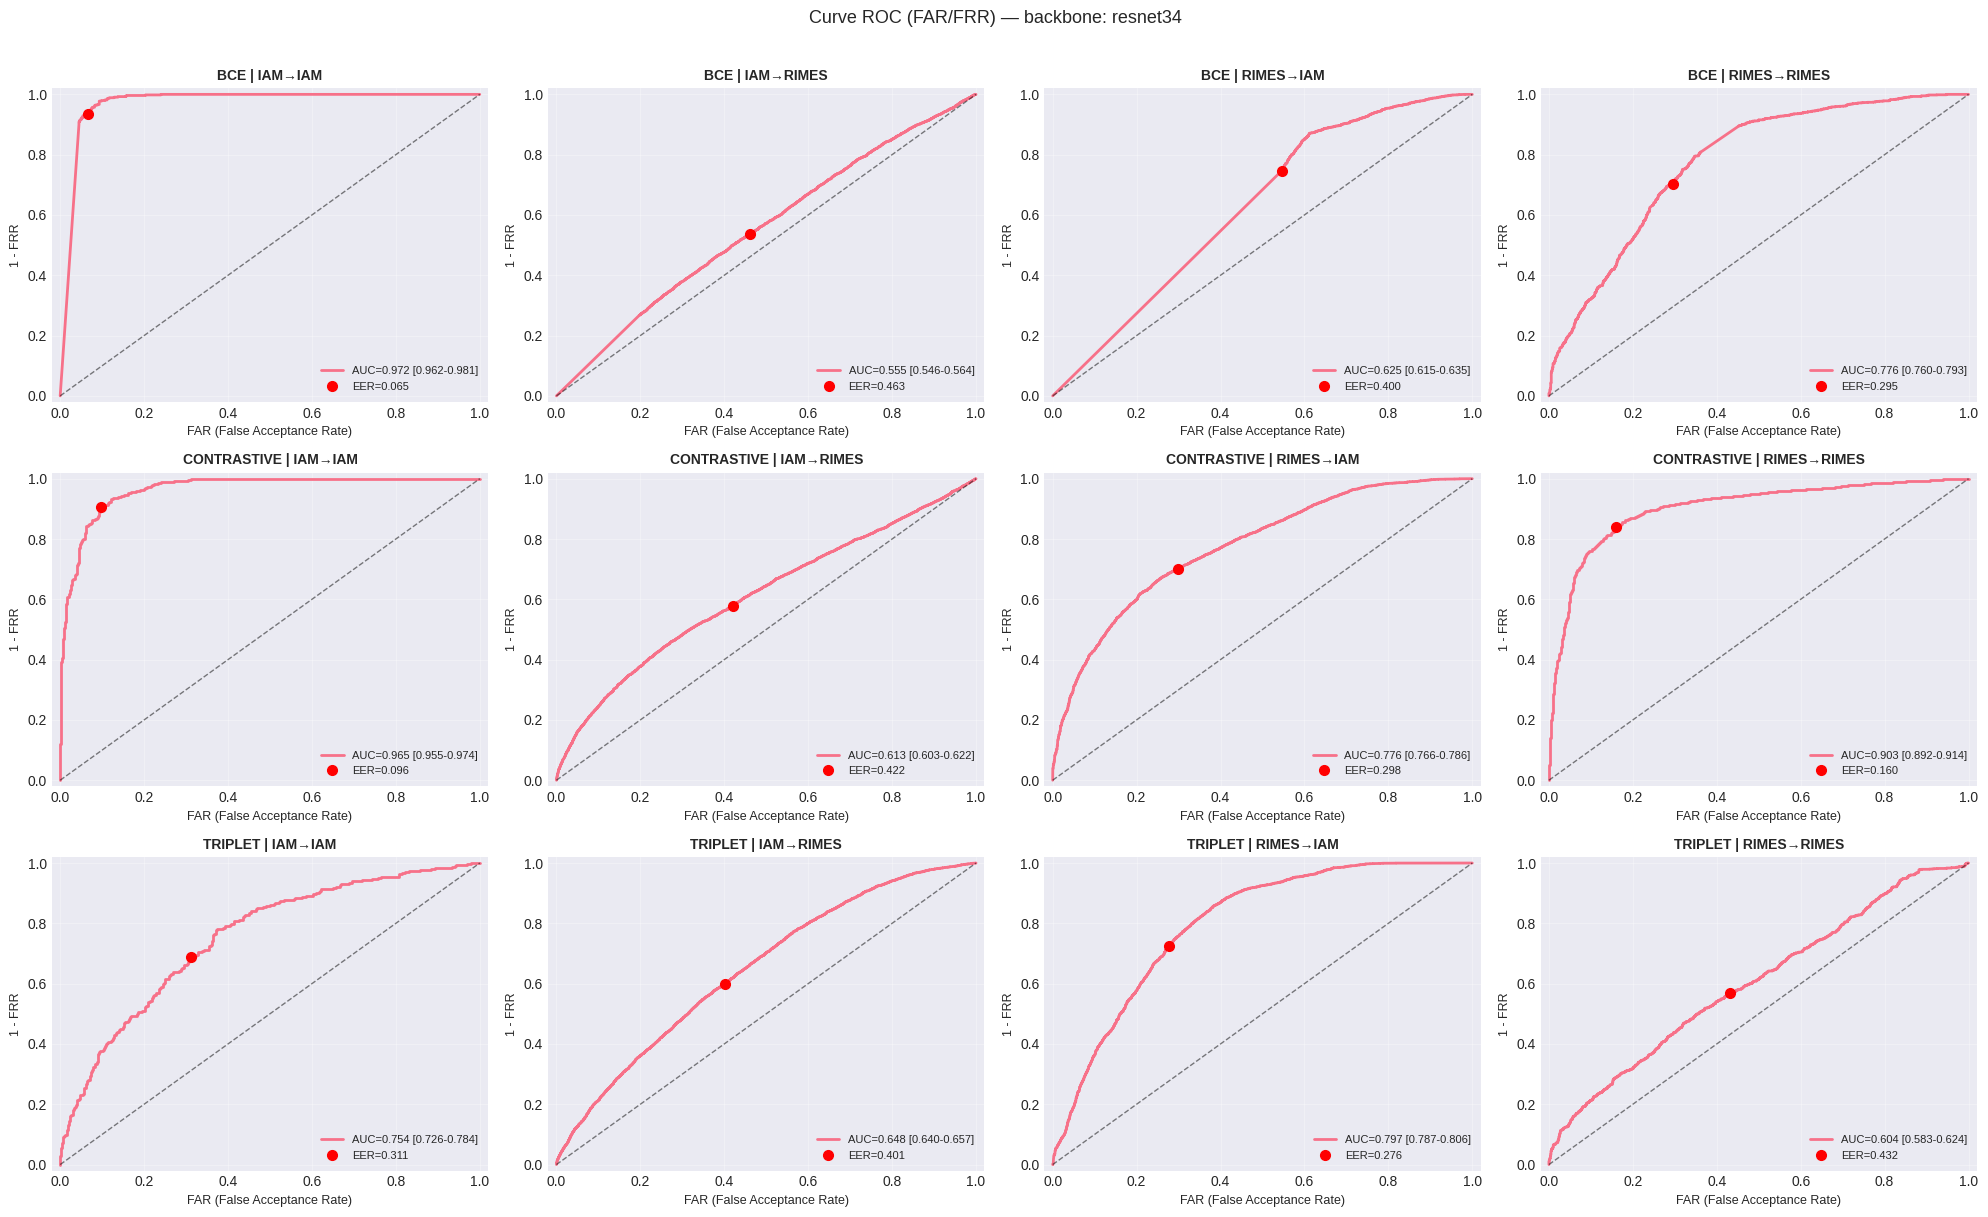

In [11]:
def plot_roc_curves(model_name):
    fig, axes = plt.subplots(len(loss_types), len(dataset_combinations),
                              figsize=(20, 4 * len(loss_types)))

    for i, loss in enumerate(loss_types):
        for j, dataset_comb in enumerate(dataset_combinations):
            ax = axes[i, j]
            m = computed_metrics.get(loss, {}).get(model_name, {}).get(dataset_comb)
            if m is None:
                ax.axis('off')
                continue

            ax.plot(m['fpr'], m['tpr'], linewidth=2,
                    label=f"AUC={m['auc']:.3f} [{m['auc_ci_low']:.3f}-{m['auc_ci_high']:.3f}]")
            ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)

            eer_idx = np.nanargmin(np.abs((1 - m['tpr']) - m['fpr']))
            ax.plot(m['fpr'][eer_idx], m['tpr'][eer_idx], 'ro', markersize=7,
                    label=f"EER={m['eer']:.3f}")

            train_ds, test_ds = dataset_comb.split('_to_')
            ax.set_title(f"{loss.upper()} | {train_ds.upper()}\u2192{test_ds.upper()}",
                         fontsize=10, fontweight='bold')
            ax.set_xlabel('FAR (False Acceptance Rate)', fontsize=9)
            ax.set_ylabel('1 - FRR', fontsize=9)
            ax.legend(fontsize=8, loc='lower right')
            ax.grid(True, alpha=0.3)
            ax.set_xlim([-0.02, 1.02])
            ax.set_ylim([-0.02, 1.02])

    fig.suptitle(f"Curve ROC (FAR/FRR) \u2014 backbone: {model_name}", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f'./images/roc_curves_{model_name}.png', dpi=300, bbox_inches='tight')
    plt.show()


if REPRESENTATIVE_MODEL in computed_metrics.get('bce', {}):
    plot_roc_curves(REPRESENTATIVE_MODEL)

## 6. DET curve (FMR vs FNMR, log-log) — modello rappresentativo

Standard de facto in biometria per il regime a bassi error rate, piu'
informativa della ROC in quella regione.

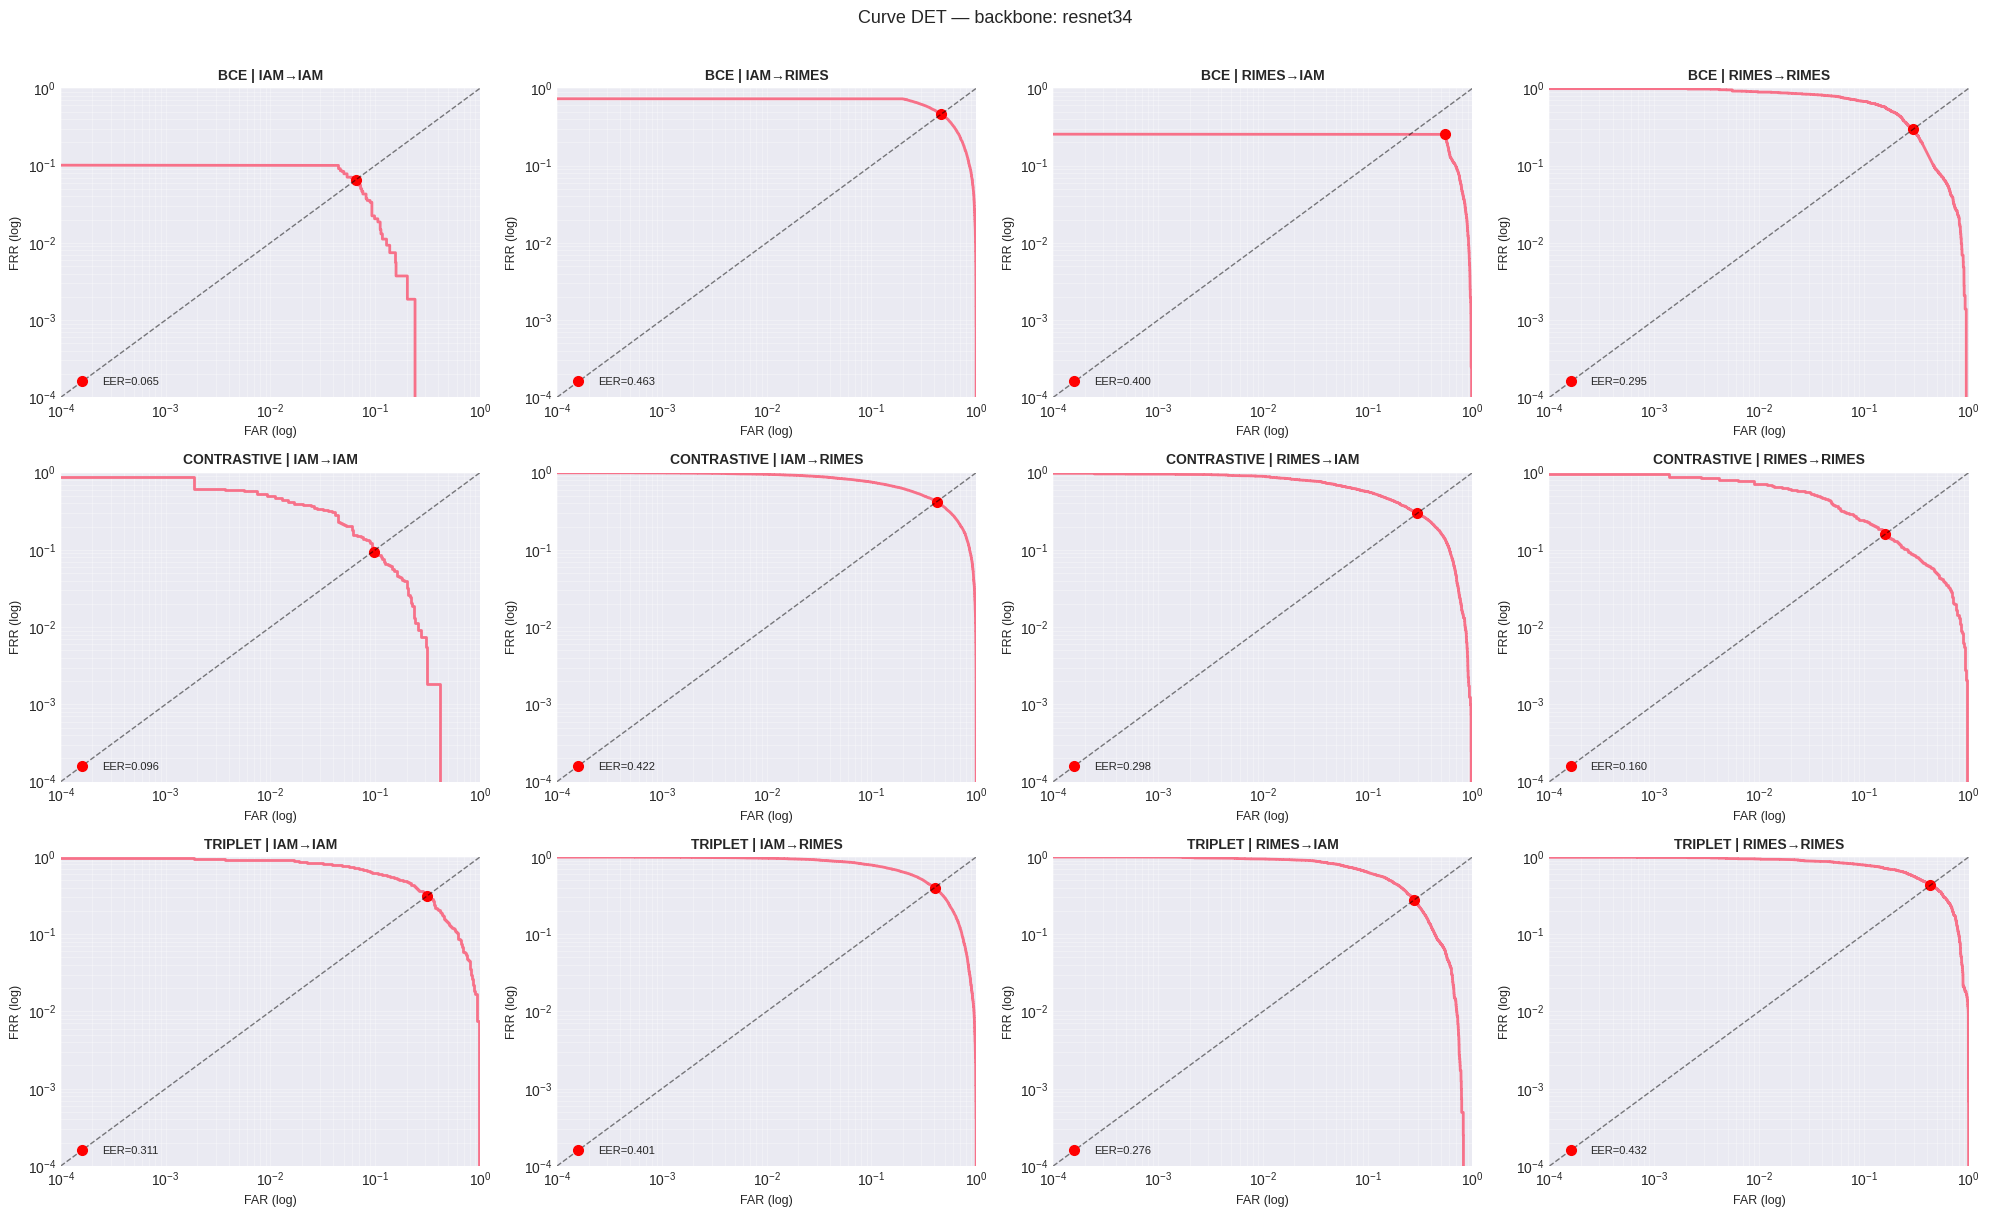

In [12]:
def plot_det_curves(model_name):
    fig, axes = plt.subplots(len(loss_types), len(dataset_combinations),
                              figsize=(20, 4 * len(loss_types)))

    for i, loss in enumerate(loss_types):
        for j, dataset_comb in enumerate(dataset_combinations):
            ax = axes[i, j]
            m = computed_metrics.get(loss, {}).get(model_name, {}).get(dataset_comb)
            if m is None:
                ax.axis('off')
                continue

            frr = 1 - m['tpr']
            ax.loglog(m['fpr'], frr, linewidth=2)

            eer_idx = np.nanargmin(np.abs(frr - m['fpr']))
            ax.plot(m['fpr'][eer_idx], frr[eer_idx], 'ro', markersize=7,
                    label=f"EER={m['eer']:.3f}")
            ax.plot([1e-4, 1], [1e-4, 1], 'k--', linewidth=1, alpha=0.5)

            train_ds, test_ds = dataset_comb.split('_to_')
            ax.set_title(f"{loss.upper()} | {train_ds.upper()}\u2192{test_ds.upper()}",
                         fontsize=10, fontweight='bold')
            ax.set_xlabel('FAR (log)', fontsize=9)
            ax.set_ylabel('FRR (log)', fontsize=9)
            ax.legend(fontsize=8, loc='lower left')
            ax.grid(True, alpha=0.3, which='both')
            ax.set_xlim([1e-4, 1])
            ax.set_ylim([1e-4, 1])

    fig.suptitle(f"Curve DET \u2014 backbone: {model_name}", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f'./images/det_curves_{model_name}.png', dpi=300, bbox_inches='tight')
    plt.show()


if REPRESENTATIVE_MODEL in computed_metrics.get('bce', {}):
    plot_det_curves(REPRESENTATIVE_MODEL)

## 7. Training history — modello rappresentativo

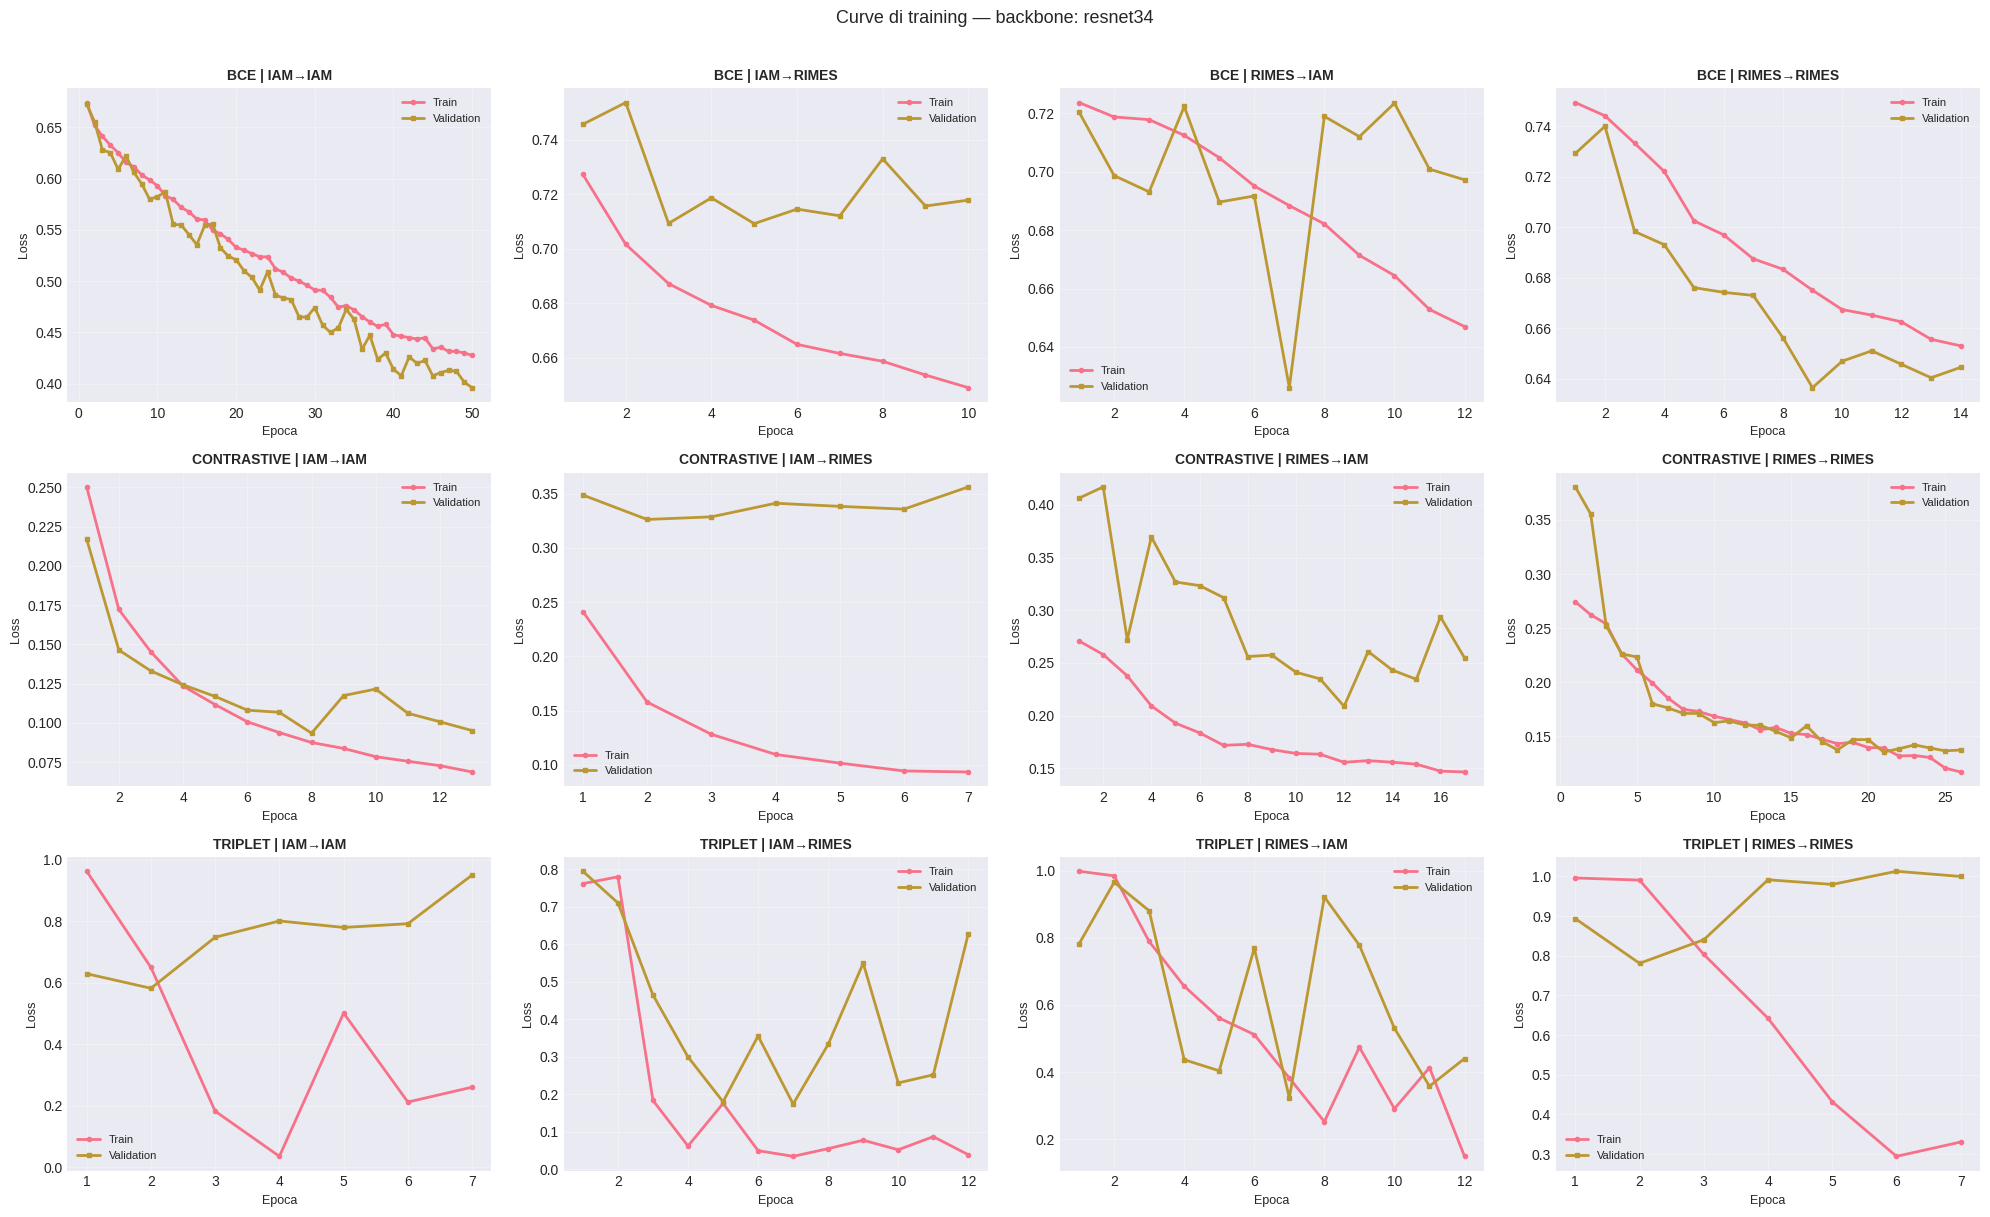

In [13]:
def plot_training_history(model_name):
    fig, axes = plt.subplots(len(loss_types), len(dataset_combinations),
                              figsize=(20, 4 * len(loss_types)))

    for i, loss in enumerate(loss_types):
        for j, dataset_comb in enumerate(dataset_combinations):
            ax = axes[i, j]
            data = all_results.get(loss, {}).get(model_name, {}).get(dataset_comb)
            if data is None:
                ax.axis('off')
                continue

            history = data['history']
            ax.plot(history['epoch'], history['train_loss'], linewidth=2,
                    label='Train', marker='o', markersize=3)
            ax.plot(history['epoch'], history['val_loss'], linewidth=2,
                    label='Validation', marker='s', markersize=3)

            train_ds, test_ds = dataset_comb.split('_to_')
            ax.set_title(f"{loss.upper()} | {train_ds.upper()}\u2192{test_ds.upper()}",
                         fontsize=10, fontweight='bold')
            ax.set_xlabel('Epoca', fontsize=9)
            ax.set_ylabel('Loss', fontsize=9)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

    fig.suptitle(f"Curve di training \u2014 backbone: {model_name}", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f'./images/training_history_{model_name}.png', dpi=300, bbox_inches='tight')
    plt.show()


if REPRESENTATIVE_MODEL in computed_metrics.get('bce', {}):
    plot_training_history(REPRESENTATIVE_MODEL)

## 8. Tabelle aggregate Same-dataset / Cross-dataset (su tutti i backbone)

Diversamente dalla versione precedente (un solo modello, un solo valore
puntuale), qui si aggrega su tutti i backbone disponibili: media,
deviazione standard e CI95% basato sulla distribuzione t (n = numero di
backbone), che e' un intervallo diverso e complementare al bootstrap CI
per-configurazione calcolato sopra.

In [14]:
def aggregate_across_models(splits_to_include, metric_keys):
    rows = []
    for loss in loss_types:
        for dataset_comb in splits_to_include:
            vals = {k: [] for k in metric_keys}
            for model_name in computed_metrics.get(loss, {}):
                m = computed_metrics[loss][model_name].get(dataset_comb)
                if m is None:
                    continue
                for k in metric_keys:
                    vals[k].append(m[k])

            n = len(vals[metric_keys[0]])
            if n == 0:
                continue

            row = {'loss': loss.upper(), 'split': dataset_comb, 'n_backbones': n}
            for k in metric_keys:
                arr = np.array(vals[k])
                mean = arr.mean()
                std = arr.std(ddof=1) if n > 1 else 0.0
                se = std / np.sqrt(n) if n > 1 else 0.0
                tcrit = stats.t.ppf(0.975, df=n - 1) if n > 1 else 0.0
                row[f'{k}_mean'] = mean
                row[f'{k}_std'] = std
                row[f'{k}_ci95_low'] = mean - tcrit * se
                row[f'{k}_ci95_high'] = mean + tcrit * se
            rows.append(row)

    return pd.DataFrame(rows)


metric_keys = ['auc', 'eer', 'd_prime', 'decidability', 'accuracy', 'f1',
               'gar_at_far_001', 'gar_at_far_01']

same_agg = aggregate_across_models(['iam_to_iam', 'rimes_to_rimes'], metric_keys)
cross_agg = aggregate_across_models(['iam_to_rimes', 'rimes_to_iam'], metric_keys)

same_agg.to_csv('./same_dataset_aggregated.csv', index=False)
cross_agg.to_csv('./cross_dataset_aggregated.csv', index=False)

print("=" * 100)
print("SAME-DATASET (aggregato su tutti i backbone, media +/- std, n=n. backbone)")
print("=" * 100)
print(same_agg[['loss', 'split', 'n_backbones', 'auc_mean', 'auc_std',
                 'eer_mean', 'eer_std', 'd_prime_mean']].round(3).to_string(index=False))

print("\n" + "=" * 100)
print("CROSS-DATASET (aggregato su tutti i backbone, media +/- std, n=n. backbone)")
print("=" * 100)
print(cross_agg[['loss', 'split', 'n_backbones', 'auc_mean', 'auc_std',
                  'eer_mean', 'eer_std', 'd_prime_mean']].round(3).to_string(index=False))

SAME-DATASET (aggregato su tutti i backbone, media +/- std, n=n. backbone)
       loss          split  n_backbones  auc_mean  auc_std  eer_mean  eer_std  d_prime_mean
        BCE     iam_to_iam            6     0.963    0.019     0.075    0.022         3.403
        BCE rimes_to_rimes            6     0.809    0.158     0.243    0.141         1.474
CONTRASTIVE     iam_to_iam            6     0.969    0.007     0.091    0.014         2.668
CONTRASTIVE rimes_to_rimes            6     0.906    0.005     0.156    0.009         1.854
    TRIPLET     iam_to_iam            6     0.797    0.042     0.282    0.035         0.885
    TRIPLET rimes_to_rimes            6     0.675    0.070     0.373    0.060         0.490

CROSS-DATASET (aggregato su tutti i backbone, media +/- std, n=n. backbone)
       loss        split  n_backbones  auc_mean  auc_std  eer_mean  eer_std  d_prime_mean
        BCE iam_to_rimes            6     0.568    0.062     0.451    0.044         0.211
        BCE rimes_to_iam

## 9. Same vs Cross dataset — confronto aggregato (tutti i backbone)

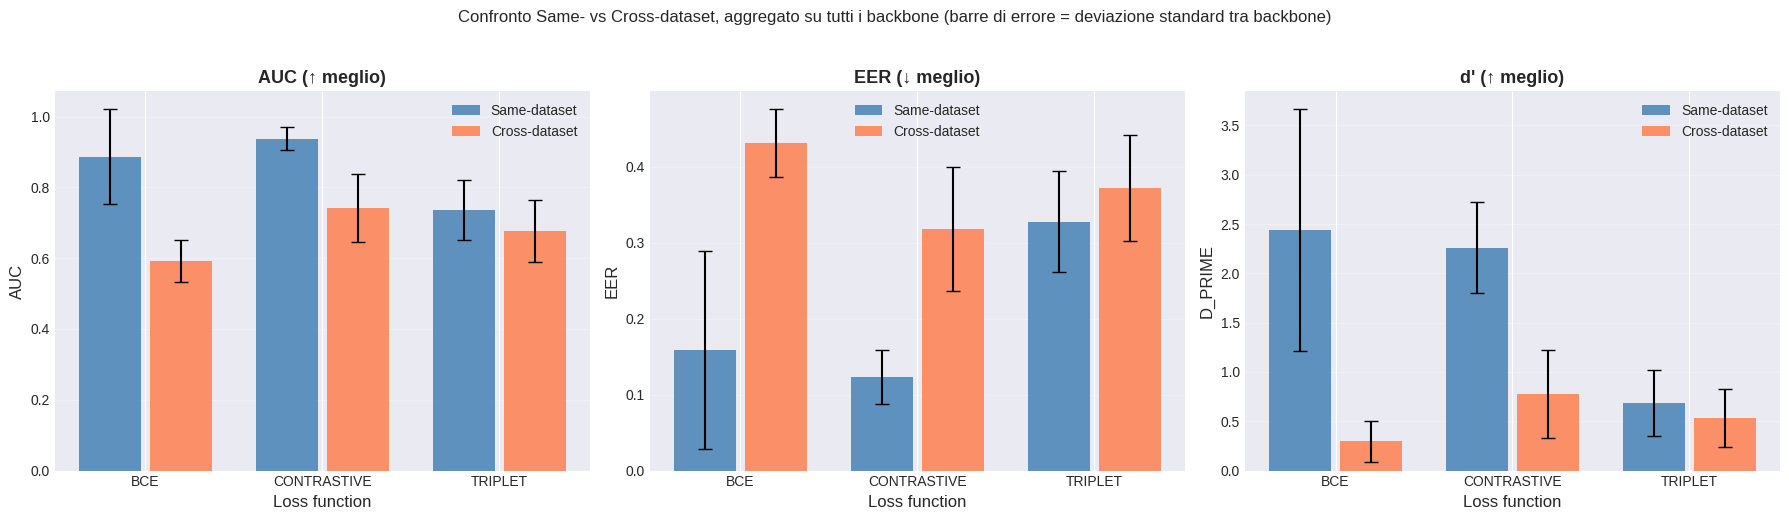

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_compare = ['auc', 'eer', 'd_prime']
titles = ['AUC (\u2191 meglio)', 'EER (\u2193 meglio)', "d' (\u2191 meglio)"]

for idx, (metric, title) in enumerate(zip(metrics_to_compare, titles)):
    ax = axes[idx]
    x_pos = 0
    x_ticks, x_labels = [], []

    for loss in loss_types:
        same_row = same_agg[(same_agg['loss'] == loss.upper())]
        cross_row = cross_agg[(cross_agg['loss'] == loss.upper())]

        same_vals_all = []
        for model_name in computed_metrics.get(loss, {}):
            for ds in ['iam_to_iam', 'rimes_to_rimes']:
                m = computed_metrics[loss][model_name].get(ds)
                if m is not None:
                    same_vals_all.append(m[metric])

        cross_vals_all = []
        for model_name in computed_metrics.get(loss, {}):
            for ds in ['iam_to_rimes', 'rimes_to_iam']:
                m = computed_metrics[loss][model_name].get(ds)
                if m is not None:
                    cross_vals_all.append(m[metric])

        if same_vals_all:
            ax.bar(x_pos, np.mean(same_vals_all), width=0.35,
                   label='Same-dataset' if x_pos == 0 else '', color='steelblue', alpha=0.85)
            ax.errorbar(x_pos, np.mean(same_vals_all), yerr=np.std(same_vals_all, ddof=1),
                        fmt='none', color='black', capsize=5)
        if cross_vals_all:
            ax.bar(x_pos + 0.4, np.mean(cross_vals_all), width=0.35,
                   label='Cross-dataset' if x_pos == 0 else '', color='coral', alpha=0.85)
            ax.errorbar(x_pos + 0.4, np.mean(cross_vals_all), yerr=np.std(cross_vals_all, ddof=1),
                        fmt='none', color='black', capsize=5)

        x_labels.append(loss.upper())
        x_ticks.append(x_pos + 0.2)
        x_pos += 1

    ax.set_xlabel('Loss function', fontsize=12)
    ax.set_ylabel(metric.upper(), fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle("Confronto Same- vs Cross-dataset, aggregato su tutti i backbone "
             "(barre di errore = deviazione standard tra backbone)", fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig('./images/same_vs_cross_comparison_aggregated.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Heatmap AUC / EER (media sui backbone)

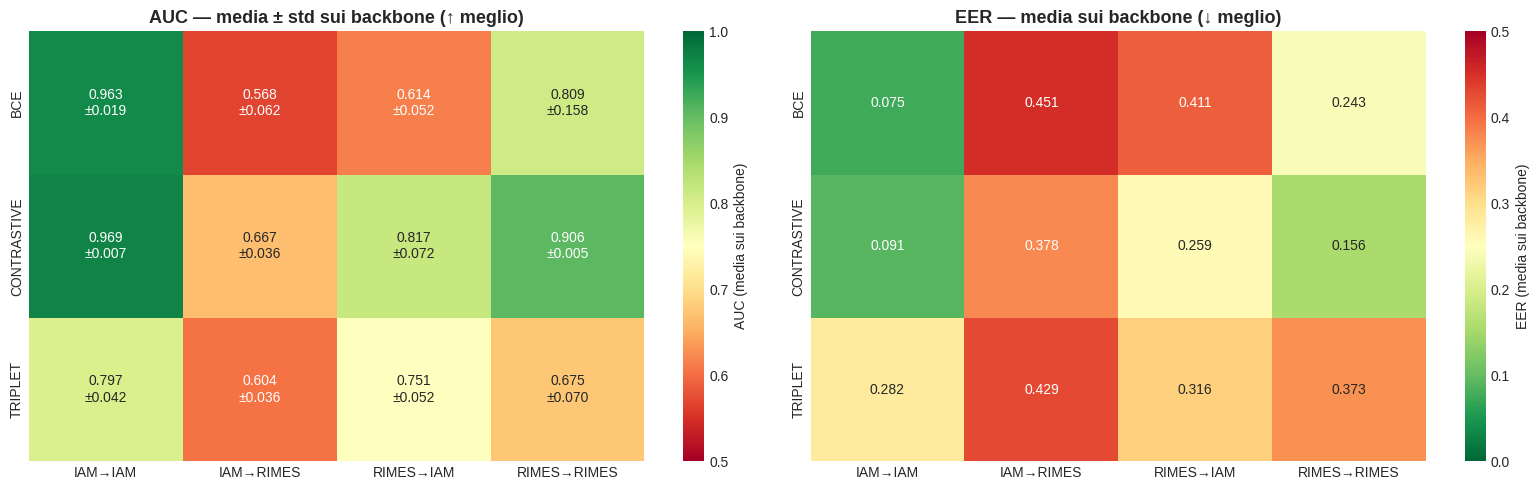

In [16]:
auc_matrix = np.full((len(loss_types), len(dataset_combinations)), np.nan)
eer_matrix = np.full((len(loss_types), len(dataset_combinations)), np.nan)
auc_std_matrix = np.full((len(loss_types), len(dataset_combinations)), np.nan)

for i, loss in enumerate(loss_types):
    for j, dataset_comb in enumerate(dataset_combinations):
        vals = [computed_metrics[loss][model_name][dataset_comb]['auc']
                for model_name in computed_metrics.get(loss, {})
                if dataset_comb in computed_metrics[loss][model_name]]
        eer_vals = [computed_metrics[loss][model_name][dataset_comb]['eer']
                    for model_name in computed_metrics.get(loss, {})
                    if dataset_comb in computed_metrics[loss][model_name]]
        if vals:
            auc_matrix[i, j] = np.mean(vals)
            auc_std_matrix[i, j] = np.std(vals, ddof=1) if len(vals) > 1 else 0.0
            eer_matrix[i, j] = np.mean(eer_vals)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

labels_x = [dc.replace('_to_', '\u2192').upper() for dc in dataset_combinations]
labels_y = [l.upper() for l in loss_types]

# annotazioni con media +/- std per l'AUC
annot_auc = np.array([[f"{auc_matrix[i,j]:.3f}\n\u00b1{auc_std_matrix[i,j]:.3f}"
                        for j in range(len(dataset_combinations))]
                       for i in range(len(loss_types))])

sns.heatmap(auc_matrix, annot=annot_auc, fmt='', cmap='RdYlGn',
            xticklabels=labels_x, yticklabels=labels_y,
            ax=axes[0], cbar_kws={'label': 'AUC (media sui backbone)'}, vmin=0.5, vmax=1.0)
axes[0].set_title("AUC \u2014 media \u00b1 std sui backbone (\u2191 meglio)", fontsize=13, fontweight='bold')

sns.heatmap(eer_matrix, annot=True, fmt='.3f', cmap='RdYlGn_r',
            xticklabels=labels_x, yticklabels=labels_y,
            ax=axes[1], cbar_kws={'label': 'EER (media sui backbone)'}, vmin=0.0, vmax=0.5)
axes[1].set_title("EER \u2014 media sui backbone (\u2193 meglio)", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('./images/metrics_heatmap_aggregated.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Test di significativita': Wilcoxon a coppie appaiate tra loss (su AUC)

Confronto appaiato per (backbone, split): ogni osservazione e' un AUC
ottenuto dalla stessa combinazione (backbone, split) sotto due loss
diverse. n = numero di backbone x numero di split (fino a 24). Riportare
statistiche + p-value + effect size, non solo la media, prima di
affermare che una loss "generalizza meglio" di un'altra.

In [17]:
def build_paired_auc(loss_a, loss_b):
    pairs = []
    for model_name in computed_metrics.get(loss_a, {}):
        for dataset_comb in computed_metrics[loss_a][model_name]:
            m_b = computed_metrics.get(loss_b, {}).get(model_name, {}).get(dataset_comb)
            if m_b is not None:
                pairs.append((
                    computed_metrics[loss_a][model_name][dataset_comb]['auc'],
                    m_b['auc'],
                ))
    if not pairs:
        return np.array([]), np.array([])
    x, y = zip(*pairs)
    return np.array(x), np.array(y)


def wilcoxon_with_effect(x, y):
    diff = x - y
    diff_nz = diff[diff != 0]
    if len(diff_nz) < 4:
        return dict(n=len(diff), n_nonzero=len(diff_nz), statistic=np.nan,
                    p_value=np.nan, effect_size=np.nan)
    ranks = stats.rankdata(np.abs(diff_nz))
    r_plus = ranks[diff_nz > 0].sum()
    r_minus = ranks[diff_nz < 0].sum()
    stat, p = stats.wilcoxon(x, y)
    effect = (r_plus - r_minus) / (r_plus + r_minus)
    return dict(n=len(diff), n_nonzero=len(diff_nz), statistic=stat,
                p_value=p, effect_size=effect)


print("=" * 100)
print("TEST DI WILCOXON A COPPIE APPAIATE SU AUC (per backbone x split)")
print("=" * 100)

wilcoxon_rows = []
for loss_a, loss_b in combinations(loss_types, 2):
    x, y = build_paired_auc(loss_a, loss_b)
    if len(x) == 0:
        continue
    res = wilcoxon_with_effect(x, y)
    res['loss_a'] = loss_a
    res['loss_b'] = loss_b
    res['mean_auc_a'] = x.mean()
    res['mean_auc_b'] = y.mean()
    wilcoxon_rows.append(res)

    sig = "significativo (p<0.05)" if (not np.isnan(res['p_value']) and res['p_value'] < 0.05) else "non significativo"
    print(f"\n{loss_a.upper()} vs {loss_b.upper()}  (n={res['n']}, n_diff\u22600={res['n_nonzero']})")
    print(f"  AUC medio: {res['mean_auc_a']:.3f} vs {res['mean_auc_b']:.3f}")
    print(f"  W={res['statistic']:.2f}  p={res['p_value']:.4f}  effect size (rank-biserial)={res['effect_size']:.3f}  -> {sig}")

wilcoxon_df = pd.DataFrame(wilcoxon_rows)
wilcoxon_df.to_csv('./wilcoxon_loss_comparison.csv', index=False)

TEST DI WILCOXON A COPPIE APPAIATE SU AUC (per backbone x split)

BCE vs CONTRASTIVE  (n=24, n_diff≠0=24)
  AUC medio: 0.739 vs 0.840
  W=14.00  p=0.0000  effect size (rank-biserial)=-0.907  -> significativo (p<0.05)

BCE vs TRIPLET  (n=24, n_diff≠0=24)
  AUC medio: 0.739 vs 0.707
  W=117.00  p=0.3596  effect size (rank-biserial)=0.220  -> non significativo

CONTRASTIVE vs TRIPLET  (n=24, n_diff≠0=24)
  AUC medio: 0.840 vs 0.707
  W=8.00  p=0.0000  effect size (rank-biserial)=0.947  -> significativo (p<0.05)


## 12. Dichiarazione dei confondimenti noti (da includere nei Results/Limitations)

Le configurazioni di training NON sono controllate in modo identico tra
le tre loss function. Chi legge il confronto tra loss deve saperlo prima
di interpretare le tabelle sopra come effetto "puro" della loss function.

In [18]:
KNOWN_CONFOUNDS = """
CONFONDIMENTI NOTI TRA LE CONFIGURAZIONI DI TRAINING (da BCE/Contrastive/Triplet notebook):

1. embedding_dim / projection_dim:
   - BCE: 32
   - Contrastive: 128
   - Triplet: 128
   BCE opera quindi con una capacita' rappresentativa 4x inferiore.

2. frozen_backbone_layers:
   - BCE: 0 (fine-tuning completo del backbone)
   - Contrastive: 3
   - Triplet: 3
   Il fine-tuning completo di BCE e' un candidato primario per spiegare il
   gap di generalizzazione cross-dataset osservato: il backbone puo'
   overfittare le feature di basso livello sul dominio sorgente.

3. batch_size:
   - BCE: 16
   - Contrastive: 32
   - Triplet: 16
   Combinato con la diversa cardinalita' di sample per epoca (TripletDataset
   genera un triplet per ogni coppia genuina, mentre BCE/Contrastive
   generano coppie genuine+impostor in rapporto 1:1), il numero di step di
   gradiente per epoca NON e' equivalente tra le tre loss a parita' di
   epochs=50.

4. dropout:
   - BCE: 0.2
   - Contrastive: 0.4
   - Triplet: 0.2

IMPLICAZIONE PER I RESULTS:
Le differenze di performance osservate tra loss function (in particolare
sulla generalizzazione cross-dataset) non possono essere attribuite alla
sola natura della loss finche' questi iperparametri non vengono uniformati
e gli esperimenti ripetuti. Il claim corretto da riportare e' del tipo
"la combinazione contrastive-loss + partial-freezing generalizza meglio
della combinazione BCE + full-finetuning", non "contrastive loss
generalizza meglio di BCE" in isolamento.

ALTRE LIMITAZIONI:
- Nessuna ripetizione multi-seed: ogni configurazione (loss, backbone,
  split) e' un singolo run. Le CI riportate sopra sono bootstrap sugli
  score di un singolo modello addestrato, NON intervalli di confidenza
  sulla varianza di training (inizializzazione, ordine dei batch, ecc.).
- La soglia usata per accuracy/precision/recall/F1 e' l'EER dello stesso
  set di validazione su cui vengono poi misurate queste metriche (nessun
  set di calibrazione indipendente): leggermente ottimistico.
- I valori mu_genuine/mu_impostor/sigma_genuine/sigma_impostor NON sono
  confrontabili in valore assoluto tra loss diverse: per BCE lo score e'
  una probabilita' sigmoid in [0,1], per contrastive/triplet e' una cosine
  similarity in [-1,1]. Solo d_prime/decidability (invarianti per
  trasformazione affine) e le metriche rank-based (AUC, EER, FAR/FRR)
  sono confrontabili cross-loss.
"""

print(KNOWN_CONFOUNDS)
with open('./known_confounds.txt', 'w', encoding='utf-8') as f:
    f.write(KNOWN_CONFOUNDS)


CONFONDIMENTI NOTI TRA LE CONFIGURAZIONI DI TRAINING (da BCE/Contrastive/Triplet notebook):

1. embedding_dim / projection_dim:
   - BCE: 32
   - Contrastive: 128
   - Triplet: 128
   BCE opera quindi con una capacita' rappresentativa 4x inferiore.

2. frozen_backbone_layers:
   - BCE: 0 (fine-tuning completo del backbone)
   - Contrastive: 3
   - Triplet: 3
   Il fine-tuning completo di BCE e' un candidato primario per spiegare il
   gap di generalizzazione cross-dataset osservato: il backbone puo'
   overfittare le feature di basso livello sul dominio sorgente.

3. batch_size:
   - BCE: 16
   - Contrastive: 32
   - Triplet: 16
   Combinato con la diversa cardinalita' di sample per epoca (TripletDataset
   genera un triplet per ogni coppia genuina, mentre BCE/Contrastive
   generano coppie genuine+impostor in rapporto 1:1), il numero di step di
   gradiente per epoca NON e' equivalente tra le tre loss a parita' di
   epochs=50.

4. dropout:
   - BCE: 0.2
   - Contrastive: 0.4
   - Tr

## 13. Tabella performance ai punti operativi FAR (Tabella mancante #1)

EER e' un buon riassunto quando FAR e FRR contano allo stesso modo, ma
non e' il regime tipico di un deployment di sicurezza (dove si fissa FAR
basso e si guarda quanto FRR/GAR ne risulta). Qui aggreghiamo su tutti i
backbone lo stesso modo delle tabelle same/cross-dataset, ma per i tre
target FAR = 1%, 0.1%, 0.01% invece che per EER.

In [19]:
def aggregate_operating_points(splits_to_include):
    far_targets = [
        ('1%', 'far_01_effective', 'frr_at_far_01', 'gar_at_far_01', None),
        ('0.1%', 'far_001_effective', 'frr_at_far_001', 'gar_at_far_001', None),
        ('0.01%', 'far_0001_effective', 'frr_at_far_0001', 'gar_at_far_0001', 'far_0001_valid'),
    ]
    rows = []
    for loss in loss_types:
        for dataset_comb in splits_to_include:
            for label, far_key, frr_key, gar_key, valid_key in far_targets:
                frr_vals, gar_vals = [], []
                for model_name in computed_metrics.get(loss, {}):
                    m = computed_metrics[loss][model_name].get(dataset_comb)
                    if m is None:
                        continue
                    if valid_key is not None and not m.get(valid_key, True):
                        continue
                    if np.isnan(m[frr_key]):
                        continue
                    frr_vals.append(m[frr_key])
                    gar_vals.append(m[gar_key])

                n = len(frr_vals)
                row = {'loss': loss.upper(), 'split': dataset_comb,
                       'far_target': label, 'n_backbones_valid': n}
                if n > 0:
                    frr_arr, gar_arr = np.array(frr_vals), np.array(gar_vals)
                    row['frr_mean'] = frr_arr.mean()
                    row['frr_std'] = frr_arr.std(ddof=1) if n > 1 else 0.0
                    row['gar_mean'] = gar_arr.mean()
                    row['gar_std'] = gar_arr.std(ddof=1) if n > 1 else 0.0
                else:
                    row['frr_mean'] = row['frr_std'] = row['gar_mean'] = row['gar_std'] = np.nan
                rows.append(row)
    return pd.DataFrame(rows)


operating_point_table = pd.concat([
    aggregate_operating_points(['iam_to_iam', 'rimes_to_rimes']),
    aggregate_operating_points(['iam_to_rimes', 'rimes_to_iam']),
], ignore_index=True)
operating_point_table.to_csv('./operating_point_table.csv', index=False)

print("=" * 100)
print("PERFORMANCE AI PUNTI OPERATIVI FAR (aggregato su tutti i backbone)")
print("Nota: n_backbones_valid < 6 significa che per alcuni backbone il punto")
print("a quel FAR e' degenere (0 coppie impostor sotto la soglia) o, per")
print("FAR=0.01%%, che gli impostor disponibili sono sotto la soglia minima")
print("(1/FAR) per una stima non degenere: quei backbone sono esclusi dalla")
print("media invece di essere riportati come se il punto fosse affidabile.")
print("=" * 100)
print(operating_point_table.round(4).to_string(index=False))

PERFORMANCE AI PUNTI OPERATIVI FAR (aggregato su tutti i backbone)
Nota: n_backbones_valid < 6 significa che per alcuni backbone il punto
a quel FAR e' degenere (0 coppie impostor sotto la soglia) o, per
FAR=0.01%%, che gli impostor disponibili sono sotto la soglia minima
(1/FAR) per una stima non degenere: quei backbone sono esclusi dalla
media invece di essere riportati come se il punto fosse affidabile.
       loss          split far_target  n_backbones_valid  frr_mean  frr_std  gar_mean  gar_std
        BCE     iam_to_iam         1%                  6    0.7685   0.3631    0.2315   0.3631
        BCE     iam_to_iam       0.1%                  6    0.9100   0.1752    0.0900   0.1752
        BCE     iam_to_iam      0.01%                  0       NaN      NaN       NaN      NaN
        BCE rimes_to_rimes         1%                  6    0.8072   0.1218    0.1928   0.1218
        BCE rimes_to_rimes       0.1%                  6    0.9317   0.0593    0.0683   0.0593
        BCE rimes_to

## 14. Tabella completa per-backbone (Tabella mancante #4, oltre alla heatmap)

La heatmap aggregata (Sezione 10) e' utile per la sezione Results, ma un
reviewer puo' chiedere il dettaglio: quale architettura beneficia di piu'
di ciascuna loss. Qui si esporta la tabella lunga completa
backbone x loss x split, da mettere in supplementare.

In [20]:
per_backbone_rows = []
for loss in loss_types:
    for model_name, splits in computed_metrics.get(loss, {}).items():
        for dataset_comb, m in splits.items():
            per_backbone_rows.append({
                'loss': loss, 'backbone': model_name, 'split': dataset_comb,
                'auc': m['auc'], 'eer': m['eer'], 'd_prime': m['d_prime'],
            })

per_backbone_df = pd.DataFrame(per_backbone_rows)
per_backbone_df.to_csv('./per_backbone_table.csv', index=False)

# Pivot leggibile: per ogni split, backbone x loss
for dataset_comb in dataset_combinations:
    sub = per_backbone_df[per_backbone_df['split'] == dataset_comb]
    if sub.empty:
        continue
    pivot = sub.pivot(index='backbone', columns='loss', values='auc')
    print(f"\nAUC per backbone x loss \u2014 split {dataset_comb}:")
    print(pivot.round(3).to_string())


AUC per backbone x loss — split iam_to_iam:
loss                  bce  contrastive  triplet
backbone                                       
efficientnet_b0     0.942        0.962    0.810
efficientnet_b1     0.978        0.974    0.779
mobilenet_v3_large  0.950        0.972    0.827
mobilenet_v3_small  0.988        0.980    0.754
resnet18            0.949        0.962    0.858
resnet34            0.972        0.965    0.754

AUC per backbone x loss — split iam_to_rimes:
loss                  bce  contrastive  triplet
backbone                                       
efficientnet_b0     0.515        0.710    0.635
efficientnet_b1     0.652        0.683    0.567
mobilenet_v3_large  0.505        0.643    0.571
mobilenet_v3_small  0.546        0.660    0.578
resnet18            0.635        0.694    0.626
resnet34            0.555        0.613    0.648

AUC per backbone x loss — split rimes_to_iam:
loss                  bce  contrastive  triplet
backbone                                     

## 15. Confronto con lo stato dell'arte (Tabella mancante #3)

I valori di letteratura NON sono calcolabili dai file di output: sono
presi da una ricerca bibliografica mirata (writer identification/
verification su IAM/RIMES o task metodologicamente affini) e vanno
verificati/aggiornati manualmente. La comparabilita' e' limitata: la
maggior parte della letteratura su IAM riporta identification accuracy/
mAP (closed-set), non EER di verifica pairwise open-set come qui; i
pochi lavori Siamese-verification con EER/AUC comparabili sono su script
diversi da IAM/RIMES. Aggiornare SOTA_LITERATURE se hai riferimenti piu'
specifici (in particolare per Afzali et al. 2024, il valore esatto non è
stato estratto con sufficiente confidenza dagli abstract disponibili).

In [21]:
SOTA_LITERATURE = [
    {'method': 'Fiel & Sablatnig (2015), CNN activation features',
     'task': 'Writer identification (closed-set)', 'dataset': 'IAM (train), ICDAR13/CVL (eval)',
     'metric': 'Accuracy/mAP', 'value': 'SOTA al momento della pubblicazione',
     'comparable': 'NO - task diverso (identification, non verification)'},
    {'method': 'Christlein et al. (2017), GMM supervector + KL-kernel',
     'task': 'Writer identification (closed-set)', 'dataset': 'ICDAR13, CVL',
     'metric': 'mAP', 'value': '+0.21 assoluto su ICDAR13 vs. SOTA precedente',
     'comparable': 'NO - task diverso'},
    {'method': 'Afzali et al. (2024), CSCNN (Siamese + combined loss)',
     'task': 'Writer verification', 'dataset': 'IAM, IFN/ENIT',
     'metric': 'EER/Accuracy', 'value': '[DA VERIFICARE SUL PDF ORIGINALE]',
     'comparable': 'PARZIALE - stesso task (verification) e IAM, script/loss diversi'},
    {'method': 'CAE + Siamese, text-independent writer verification (2019)',
     'task': 'Writer verification', 'dataset': 'non IAM/RIMES (script non confermato)',
     'metric': 'EER / AUC', 'value': 'EER=26.4%, AUC=0.818',
     'comparable': 'PARZIALE - stesse metriche, dataset diverso'},
    {'method': 'Scribe verification, Siamese/Triplet (ResNet18/34, MobileNetV3, ecc.)',
     'task': 'Writer/scribe verification (stessa famiglia protocollare)',
     'dataset': 'Tsinghua Bamboo Slips, MCCD (manoscritti cinesi)',
     'metric': 'AUC / errore tipo-EER',
     'value': 'AUC 0.86-0.96; errore ~7.8-21% a seconda di backbone/corpus',
     'comparable': 'PARZIALE - stessi backbone e protocollo, dominio/script diverso'},
]
sota_df = pd.DataFrame(SOTA_LITERATURE)

# Best-of-ours, calcolato dinamicamente dai dati effettivamente caricati
best_rows = []
for dataset_comb in dataset_combinations:
    best = None
    for loss in loss_types:
        for model_name in computed_metrics.get(loss, {}):
            m = computed_metrics[loss][model_name].get(dataset_comb)
            if m is None:
                continue
            if best is None or m['auc'] > best['auc']:
                best = dict(loss=loss, backbone=model_name, split=dataset_comb,
                            auc=m['auc'], eer=m['eer'])
    if best:
        best_rows.append(best)
ours_best_df = pd.DataFrame(best_rows)

sota_df.to_csv('./sota_literature.csv', index=False)
ours_best_df.to_csv('./ours_best_per_split.csv', index=False)

print("=" * 100)
print("CONFRONTO CON LA LETTERATURA (vedi note di comparabilita' in ogni riga)")
print("=" * 100)
print(sota_df.to_string(index=False))
print("\nMiglior configurazione nostra per split (calcolata dai dati caricati):")
print(ours_best_df.round(3).to_string(index=False) if not ours_best_df.empty else "  (nessun dato caricato)")

CONFRONTO CON LA LETTERATURA (vedi note di comparabilita' in ogni riga)
                                                               method                                                      task                                          dataset                metric                                                       value                                                       comparable
                     Fiel & Sablatnig (2015), CNN activation features                        Writer identification (closed-set)                  IAM (train), ICDAR13/CVL (eval)          Accuracy/mAP                         SOTA al momento della pubblicazione             NO - task diverso (identification, non verification)
                Christlein et al. (2017), GMM supervector + KL-kernel                        Writer identification (closed-set)                                     ICDAR13, CVL                   mAP               +0.21 assoluto su ICDAR13 vs. SOTA precedente                      

## 16. Analisi dei fallimenti: top-10 false accept / false reject (Tabella mancante #8)

Prova prima a caricare metadata a livello di coppia (path immagine,
writer ID), se lo script di valutazione li salva in un file accanto ai
CSV di metriche. Se non li trova, esegue comunque il ranking sugli score
(senza immagini/writer ID) e stampa un messaggio esplicito su cosa
salvare in fase di valutazione per abilitare l'analisi completa con
immagini — verificare lo script di evaluation per questo.

In [22]:
def try_load_pair_metadata(experiment_path, experiment_name):
    """Cerca un file di metadata a livello di coppia. Pattern tentati,
    da adattare al nome reale usato dal tuo script di valutazione se
    diverso da questi."""
    candidates = [
        experiment_path / f"{experiment_name}_pairs.csv",
        experiment_path / f"{experiment_name}_pair_details.csv",
        experiment_path / "pairs.csv",
    ]
    for c in candidates:
        if c.exists():
            return pd.read_csv(c)
    return None


def failure_case_analysis(loss, model_name, dataset_comb, top_n=10):
    data = all_results.get(loss, {}).get(model_name, {}).get(dataset_comb)
    if data is None:
        return None, None, False

    genuine = data['genuine_vals']
    impostor = data['impostor_vals']
    m = computed_metrics[loss][model_name][dataset_comb]
    thr = m['eer_threshold']

    experiment_path, experiment_name = resolve_experiment_path(loss, model_name, dataset_comb)
    pair_meta = try_load_pair_metadata(experiment_path, experiment_name) if experiment_path else None
    has_meta = pair_meta is not None and {'pair_type'}.issubset(pair_meta.columns)

    if has_meta:
        fa = pair_meta[(pair_meta['pair_type'] == 'impostor') & (pair_meta['score'] >= thr)]
        fa = fa.sort_values('score', ascending=False).head(top_n)
        fr = pair_meta[(pair_meta['pair_type'] == 'genuine') & (pair_meta['score'] < thr)]
        fr = fr.sort_values('score', ascending=True).head(top_n)
        return fa, fr, True

    # Fallback: solo score, senza path/writer ID
    fa_scores = np.sort(impostor[impostor >= thr])[::-1][:top_n]
    fr_scores = np.sort(genuine[genuine < thr])[:top_n]
    fa = pd.DataFrame({'rank': range(1, len(fa_scores) + 1), 'score': fa_scores})
    fr = pd.DataFrame({'rank': range(1, len(fr_scores) + 1), 'score': fr_scores})
    return fa, fr, False


print("=" * 100)
print("FAILURE CASE ANALYSIS: top false accept / top false reject")
print("=" * 100)

failure_meta_available = False
for dataset_comb in dataset_combinations:
    if not ours_best_df.empty:
        row = ours_best_df[ours_best_df['split'] == dataset_comb]
        if row.empty:
            continue
        loss, model_name = row.iloc[0]['loss'], row.iloc[0]['backbone']
    else:
        continue

    fa, fr, has_meta = failure_case_analysis(loss, model_name, dataset_comb)
    failure_meta_available = failure_meta_available or has_meta
    print(f"\n--- {dataset_comb} | miglior config: {loss}/{model_name} ---")
    if fa is not None:
        fa.to_csv(f'./top_false_accepts_{dataset_comb}.csv', index=False)
        fr.to_csv(f'./top_false_rejects_{dataset_comb}.csv', index=False)
        print(f"Top false accepts (n={len(fa)}) e top false rejects (n={len(fr)}) "
              f"salvati in CSV. Metadata path/writer ID {'TROVATI' if has_meta else 'NON TROVATI'}.")

if not failure_meta_available:
    print("""
ATTENZIONE: nessun file di metadata a livello di coppia (path immagine,
writer ID) e' stato trovato per nessuna configurazione: la failure
analysis sopra e' basata solo sugli score, senza poter mostrare le
immagini ne' identificare quali writer causano piu' errori.
Per abilitare l'analisi completa con immagini (richiesta nel punto #8),
lo script di VALUTAZIONE (non questo notebook di analisi) deve salvare,
per ogni coppia genuine/impostor valutata, almeno: path immagine 1, path
immagine 2, writer ID 1, writer ID 2, score, pair_type — in un file
tipo '<experiment_name>_pairs.csv' accanto ai file gia' salvati
('..._final_metrics.csv', '..._history.csv'). Una volta disponibile,
questo notebook lo user\u00e0 automaticamente (vedi try_load_pair_metadata)
per produrre anche le figure con le immagini affiancate.
""")

FAILURE CASE ANALYSIS: top false accept / top false reject

--- iam_to_iam | miglior config: bce/mobilenet_v3_small ---
Top false accepts (n=10) e top false rejects (n=10) salvati in CSV. Metadata path/writer ID NON TROVATI.

--- iam_to_rimes | miglior config: contrastive/efficientnet_b0 ---
Top false accepts (n=10) e top false rejects (n=10) salvati in CSV. Metadata path/writer ID NON TROVATI.

--- rimes_to_iam | miglior config: contrastive/resnet18 ---
Top false accepts (n=10) e top false rejects (n=10) salvati in CSV. Metadata path/writer ID NON TROVATI.

--- rimes_to_rimes | miglior config: bce/mobilenet_v3_small ---
Top false accepts (n=10) e top false rejects (n=10) salvati in CSV. Metadata path/writer ID NON TROVATI.

ATTENZIONE: nessun file di metadata a livello di coppia (path immagine,
writer ID) e' stato trovato per nessuna configurazione: la failure
analysis sopra e' basata solo sugli score, senza poter mostrare le
immagini ne' identificare quali writer causano piu' errori.

## 17. DET aggregata: miglior modello vs. media sui backbone (Figura mancante #6)

Invece di scegliere un solo backbone "rappresentativo" (ResNet-34) per
le curve DET, qui si sovrappone la curva DET del miglior modello per
ogni split alla curva media (+/- 1 std) calcolata punto per punto su una
griglia comune di FAR, per tutti i backbone disponibili sotto la loss
migliore di quello split.

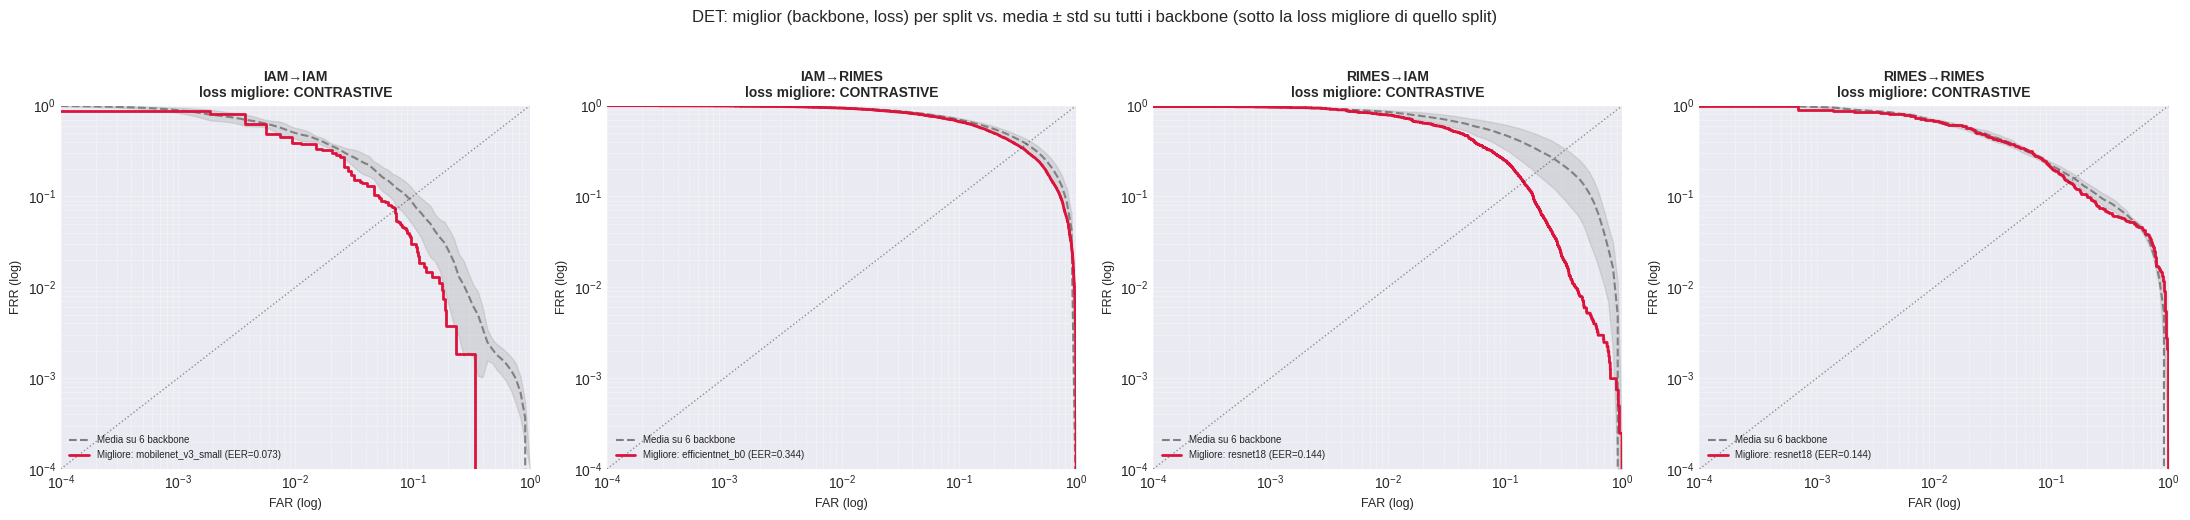

In [23]:
def det_curve_on_grid(m, far_grid):
    """Interpola FRR sulla griglia di FAR comune (necessario per poter
    fare media/std punto per punto tra backbone diversi, che hanno soglie
    e quindi punti (FAR, FRR) non allineati)."""
    fpr, frr = m['fpr'], 1 - m['tpr']
    order = np.argsort(fpr)
    fpr_sorted, frr_sorted = fpr[order], frr[order]
    fpr_sorted, unique_idx = np.unique(fpr_sorted, return_index=True)
    frr_sorted = frr_sorted[unique_idx]
    return np.interp(far_grid, fpr_sorted, frr_sorted)


far_grid = np.logspace(-4, 0, 100)
fig, axes = plt.subplots(1, len(dataset_combinations), figsize=(22, 5))

for j, dataset_comb in enumerate(dataset_combinations):
    ax = axes[j]

    # loss migliore per questo split, in base all'AUC medio aggregato
    best_loss, best_auc = None, -np.inf
    for loss in loss_types:
        vals = [computed_metrics[loss][mn][dataset_comb]['auc']
                for mn in computed_metrics.get(loss, {}) if dataset_comb in computed_metrics[loss][mn]]
        if vals and np.mean(vals) > best_auc:
            best_auc, best_loss = np.mean(vals), loss

    if best_loss is None:
        ax.axis('off')
        continue

    frr_curves, backbone_eers = [], {}
    for model_name in computed_metrics.get(best_loss, {}):
        m = computed_metrics[best_loss][model_name].get(dataset_comb)
        if m is None:
            continue
        frr_curves.append(det_curve_on_grid(m, far_grid))
        backbone_eers[model_name] = m['eer']

    if not frr_curves:
        ax.axis('off')
        continue

    frr_curves = np.array(frr_curves)
    frr_mean = frr_curves.mean(axis=0)
    frr_std = frr_curves.std(axis=0, ddof=1) if len(frr_curves) > 1 else np.zeros_like(frr_mean)

    best_backbone = min(backbone_eers, key=backbone_eers.get)
    m_best = computed_metrics[best_loss][best_backbone][dataset_comb]

    ax.loglog(far_grid, frr_mean, '--', color='gray', linewidth=1.5,
              label=f'Media su {len(frr_curves)} backbone')
    ax.fill_between(far_grid, np.clip(frr_mean - frr_std, 1e-4, 1), np.clip(frr_mean + frr_std, 1e-4, 1),
                     color='gray', alpha=0.2)
    ax.loglog(m_best['fpr'], 1 - m_best['tpr'], color='crimson', linewidth=2,
              label=f'Migliore: {best_backbone} (EER={m_best["eer"]:.3f})')
    ax.loglog([1e-4, 1], [1e-4, 1], 'k:', linewidth=1, alpha=0.4)

    train_ds, test_ds = dataset_comb.split('_to_')
    ax.set_title(f"{train_ds.upper()}\u2192{test_ds.upper()}\nloss migliore: {best_loss.upper()}",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('FAR (log)', fontsize=9)
    ax.set_ylabel('FRR (log)', fontsize=9)
    ax.legend(fontsize=7, loc='lower left')
    ax.grid(True, alpha=0.3, which='both')
    ax.set_xlim([1e-4, 1])
    ax.set_ylim([1e-4, 1])

fig.suptitle("DET: miglior (backbone, loss) per split vs. media \u00b1 std su tutti i backbone "
             "(sotto la loss migliore di quello split)", fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig('./images/det_best_vs_aggregated.png', dpi=300, bbox_inches='tight')
plt.show()

## 18. Export riassuntivo per la stesura dei Results

Un'unica tabella "lunga" con tutte le configurazioni, metriche puntuali
e CI bootstrap: e' la base dati da cui estrarre le tabelle del paper.

In [24]:
export_rows = []
for loss in loss_types:
    for model_name, splits in computed_metrics.get(loss, {}).items():
        for dataset_comb, m in splits.items():
            export_rows.append({
                'loss': loss, 'backbone': model_name, 'split': dataset_comb,
                'n_genuine': len(all_results[loss][model_name][dataset_comb]['genuine_vals']),
                'n_impostor': len(all_results[loss][model_name][dataset_comb]['impostor_vals']),
                'auc': m['auc'], 'auc_ci95_low': m['auc_ci_low'], 'auc_ci95_high': m['auc_ci_high'],
                'eer': m['eer'], 'eer_ci95_low': m['eer_ci_low'], 'eer_ci95_high': m['eer_ci_high'],
                'd_prime': m['d_prime'], 'decidability': m['decidability'],
                'accuracy_at_eer': m['accuracy'], 'precision_at_eer': m['precision'],
                'recall_at_eer': m['recall'], 'f1_at_eer': m['f1'],
                'frr_at_far_1pct': m['frr_at_far_01'], 'gar_at_far_1pct': m['gar_at_far_01'],
                'frr_at_far_0.1pct': m['frr_at_far_001'], 'gar_at_far_0.1pct': m['gar_at_far_001'],
                'frr_at_far_0.01pct': m['frr_at_far_0001'], 'gar_at_far_0.01pct': m['gar_at_far_0001'],
                'far_0.01pct_valid': m['far_0001_valid'],
            })

final_export = pd.DataFrame(export_rows).sort_values(['loss', 'backbone', 'split'])
final_export.to_csv('./results_full_export.csv', index=False)
print(f"Esportate {len(final_export)} configurazioni in results_full_export.csv")
print(final_export.head(10).to_string(index=False))

print("\n" + "=" * 100)
print("RIEPILOGO FILE GENERATI PER LA STESURA DEI RESULTS")
print("=" * 100)
print("""
  protocol_table.csv              -> Tabella 1 (protocollo)
  writer_stats.csv                -> Tabella 2 (writer/dataset)      [NUOVO]
  same_dataset_aggregated.csv     -> Tabella same-dataset
  cross_dataset_aggregated.csv    -> Tabella cross-dataset
  operating_point_table.csv       -> Tabella FAR/FRR/GAR operativi   [NUOVO]
  per_backbone_table.csv          -> Tabella completa per backbone   [NUOVO]
  wilcoxon_loss_comparison.csv    -> Test di significativita'
  sota_literature.csv             -> Confronto con la letteratura    [NUOVO]
  ours_best_per_split.csv         -> Nostra miglior config per split [NUOVO]
  top_false_accepts_<split>.csv   -> Failure analysis                [NUOVO]
  top_false_rejects_<split>.csv   -> Failure analysis                [NUOVO]
  known_confounds.txt             -> Blocco Limitations
  results_full_export.csv         -> Tabella lunga completa (tutte le config)
  images/metrics_heatmap_aggregated.png    -> Heatmap per-backbone
  images/det_best_vs_aggregated.png        -> DET migliore vs. media [NUOVO]
""")

Esportate 72 configurazioni in results_full_export.csv
loss           backbone          split  n_genuine  n_impostor      auc  auc_ci95_low  auc_ci95_high      eer  eer_ci95_low  eer_ci95_high  d_prime  decidability  accuracy_at_eer  precision_at_eer  recall_at_eer  f1_at_eer  frr_at_far_1pct  gar_at_far_1pct  frr_at_far_0.1pct  gar_at_far_0.1pct  frr_at_far_0.01pct  gar_at_far_0.01pct  far_0.01pct_valid
 bce    efficientnet_b0     iam_to_iam        537         537 0.941682      0.927742       0.955527 0.088454      0.071695       0.105214 3.008535      3.008535         0.911546          0.904762       0.919926   0.912281         1.000000         0.000000           1.000000           0.000000                 NaN                 NaN              False
 bce    efficientnet_b0   iam_to_rimes       7175        7175 0.515172      0.509530       0.520671 0.484599      0.479162       0.490244 0.045374      0.045374         0.515401          0.508764       0.894077   0.648504         1.000000 